# Two-asset allocation with asset-specific jump-model regimes


## Warning 

- The jump-model teacher states are fit on the **full sample**, so regime labels are **hindsight-contaminated**.
- The carry-forward benchmark and lambda choice are built from those same full-sample labels, so model selection is **biased**.
- The supervised forecasting section is walk-forward in form, but its targets come from a **leaked teacher**, so it is **not fully out-of-sample**.
- Some allocation inputs, e.g. regime-conditioned means, also inherit this contamination.

In [65]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 320)
pd.set_option("display.max_colwidth", 200)
pd.options.display.float_format = "{:.6f}".format


In [66]:
NOTEBOOK_DIR = Path.cwd()

SOURCE_PATH = NOTEBOOK_DIR / "model_panel_start_1970_01_31.parquet"
TRUNC_DATE = pd.Timestamp("2024-11-30")

if not SOURCE_PATH.exists():
    raise FileNotFoundError(f"Missing required input file: {SOURCE_PATH.name}")

print("NOTEBOOK_DIR")
print(NOTEBOOK_DIR)
print()
print("SOURCE_PATH")
print(SOURCE_PATH)
print()
print("TRUNC_DATE")
print(TRUNC_DATE.date())


NOTEBOOK_DIR
g:\My Drive\onedrive migration\YEAR 202526\ML IN FINANCE AND COMPLEX SYSTEMS\Bayesian-Macro-Regime-Mapping\Asset allocation with asset specific regime forecasts\two_asset_allocation_sjm

SOURCE_PATH
g:\My Drive\onedrive migration\YEAR 202526\ML IN FINANCE AND COMPLEX SYSTEMS\Bayesian-Macro-Regime-Mapping\Asset allocation with asset specific regime forecasts\two_asset_allocation_sjm\model_panel_start_1970_01_31.parquet

TRUNC_DATE
2024-11-30


In [67]:
panel_raw = pd.read_parquet(SOURCE_PATH).copy()
panel_raw["date"] = pd.to_datetime(panel_raw["date"])
panel_raw = panel_raw.sort_values("date").reset_index(drop=True)

print("RAW_PANEL_SUMMARY")
print(
    pd.DataFrame(
        {
            "item": ["n_rows", "n_cols", "start_date", "end_date"],
            "value": [
                panel_raw.shape[0],
                panel_raw.shape[1],
                str(panel_raw["date"].min().date()),
                str(panel_raw["date"].max().date()),
            ],
        }
    ).to_string(index=False)
)


RAW_PANEL_SUMMARY
      item      value
    n_rows        675
    n_cols        274
start_date 1970-01-31
  end_date 2026-03-31


In [68]:
required_cols = [
    "date",
    "sprtrn_sp500",
    "agg_ret",
    "rf",
    "sp500_fwd_excess_1m",
    "bond_fwd_excess_1m",
    "sp500_fwd_excess_3m",
    "bond_fwd_excess_3m",
    "sp500_fwd_excess_6m",
    "bond_fwd_excess_6m",
    "derived_y_2Y_wrds_diff_1_wrds",
    "derived_slope_10y_2y_wrds",
    "VIXCLSx",
]


panel = panel_raw.loc[panel_raw["date"] <= TRUNC_DATE, required_cols].copy()

numeric_cols = [col for col in panel.columns if col != "date"]
for col in numeric_cols:
    panel[col] = pd.to_numeric(panel[col], errors="coerce").astype("float64")

panel["equity_excess"] = panel["sprtrn_sp500"] - panel["rf"]
panel["bond_excess"] = panel["agg_ret"] - panel["rf"]

horizon_cutoffs = {
    "1m": TRUNC_DATE - pd.offsets.MonthEnd(1),
    "3m": TRUNC_DATE - pd.offsets.MonthEnd(3),
    "6m": TRUNC_DATE - pd.offsets.MonthEnd(6),
}

forward_cols_by_horizon = {
    "1m": ["sp500_fwd_excess_1m", "bond_fwd_excess_1m"],
    "3m": ["sp500_fwd_excess_3m", "bond_fwd_excess_3m"],
    "6m": ["sp500_fwd_excess_6m", "bond_fwd_excess_6m"],
}

for horizon, cols in forward_cols_by_horizon.items():
    bad_mask = panel["date"] > horizon_cutoffs[horizon]
    panel.loc[bad_mask, cols] = np.nan

ordered_cols = [
    "date",
    "sprtrn_sp500",
    "agg_ret",
    "rf",
    "equity_excess",
    "bond_excess",
    "sp500_fwd_excess_1m",
    "bond_fwd_excess_1m",
    "sp500_fwd_excess_3m",
    "bond_fwd_excess_3m",
    "sp500_fwd_excess_6m",
    "bond_fwd_excess_6m",
    "derived_y_2Y_wrds_diff_1_wrds",
    "derived_slope_10y_2y_wrds",
    "VIXCLSx",
]
panel = panel[ordered_cols].reset_index(drop=True)

print("BASE_PANEL_SUMMARY")
print(
    pd.DataFrame(
        {
            "item": ["n_rows", "n_cols", "start_date", "end_date"],
            "value": [
                panel.shape[0],
                panel.shape[1],
                str(panel["date"].min().date()),
                str(panel["date"].max().date()),
            ],
        }
    ).to_string(index=False)
)
print()
print("BASE_PANEL_TAIL")
print(panel.tail(12).to_string(index=False))

BASE_PANEL_PATH = NOTEBOOK_DIR / "base_panel_monthly_trunc_2024_11.parquet"
panel.to_parquet(BASE_PANEL_PATH, index=False)

print()
print("BASE_PANEL_FILE")
print(BASE_PANEL_PATH.name)
print()


BASE_PANEL_SUMMARY
      item      value
    n_rows        659
    n_cols         15
start_date 1970-01-31
  end_date 2024-11-30

BASE_PANEL_TAIL
      date  sprtrn_sp500   agg_ret       rf  equity_excess  bond_excess  sp500_fwd_excess_1m  bond_fwd_excess_1m  sp500_fwd_excess_3m  bond_fwd_excess_3m  sp500_fwd_excess_6m  bond_fwd_excess_6m  derived_y_2Y_wrds_diff_1_wrds  derived_slope_10y_2y_wrds   VIXCLSx
2023-12-31      0.044229  0.038280 0.004300       0.039929     0.033980             0.011196           -0.007447             0.088323           -0.021015             0.118105           -0.033801                      -0.422360                  -0.357816 12.696000
2024-01-31      0.015896 -0.002747 0.004700       0.011196    -0.007447             0.047521           -0.018328             0.025961           -0.043415             0.113153           -0.007606                      -0.061278                  -0.262644 13.345300
2024-02-29      0.051721 -0.014128 0.004200       0.047521    -0.

## Final feature construction


In [69]:
feature_source_required = [
    "date",
    "sprtrn_sp500",
    "agg_ret",
    "rf",
    "derived_y_2Y_wrds_diff_1_wrds",
    "derived_slope_10y_2y_wrds",
    "VIXCLSx",
]

feature_source = panel_raw.loc[panel_raw["date"] <= TRUNC_DATE].copy().reset_index(drop=True)

feature_source["sprtrn_sp500"] = pd.to_numeric(feature_source["sprtrn_sp500"], errors="coerce").astype("float64")
feature_source["agg_ret"] = pd.to_numeric(feature_source["agg_ret"], errors="coerce").astype("float64")
feature_source["rf"] = pd.to_numeric(feature_source["rf"], errors="coerce").astype("float64")
feature_source["derived_y_2Y_wrds_diff_1_wrds"] = pd.to_numeric(feature_source["derived_y_2Y_wrds_diff_1_wrds"], errors="coerce").astype("float64")
feature_source["derived_slope_10y_2y_wrds"] = pd.to_numeric(feature_source["derived_slope_10y_2y_wrds"], errors="coerce").astype("float64")
feature_source["VIXCLSx"] = pd.to_numeric(feature_source["VIXCLSx"], errors="coerce").astype("float64")

feature_source["equity_excess"] = feature_source["sprtrn_sp500"] - feature_source["rf"]
feature_source["bond_excess"] = feature_source["agg_ret"] - feature_source["rf"]

print("FEATURE_SOURCE_SUMMARY")
print(
    pd.DataFrame(
        {
            "item": ["n_rows", "n_cols", "start_date", "end_date"],
            "value": [
                feature_source.shape[0],
                feature_source.shape[1],
                str(feature_source["date"].min().date()),
                str(feature_source["date"].max().date()),
            ],
        }
    ).to_string(index=False)
)


FEATURE_SOURCE_SUMMARY
      item      value
    n_rows        659
    n_cols        276
start_date 1970-01-31
  end_date 2024-11-30


In [70]:
EPS = 1e-12
HALFLIFE_MAP = {"h1": 1, "h2": 2, "h4": 4}

def ewm_mean(series: pd.Series, halflife: float) -> pd.Series:
    return series.ewm(halflife=halflife, adjust=False).mean()

def ewm_std(series: pd.Series, halflife: float) -> pd.Series:
    return series.ewm(halflife=halflife, adjust=False).std(bias=False)

def ewm_downside_dev(series: pd.Series, halflife: float) -> pd.Series:
    downside_sq = series.clip(upper=0.0).pow(2)
    return np.sqrt(downside_sq.ewm(halflife=halflife, adjust=False).mean())

def build_return_family(df: pd.DataFrame, source_col: str, prefix: str, ratio_name: str) -> pd.DataFrame:
    out = pd.DataFrame({"date": df["date"]}).copy()
    s = pd.to_numeric(df[source_col], errors="coerce")

    for label, halflife in HALFLIFE_MAP.items():
        mean_col = f"{prefix}_mean_{label}"
        dd_col = f"{prefix}_dd_{label}"
        logdd_col = f"{prefix}_logdd_{label}"
        std_col = f"{prefix}_std_{label}"
        ratio_col = f"{prefix}_{ratio_name}_{label}"

        out[mean_col] = ewm_mean(s, halflife)
        out[dd_col] = ewm_downside_dev(s, halflife)
        out[logdd_col] = np.log(out[dd_col] + EPS)
        out[std_col] = ewm_std(s, halflife)

        if ratio_name == "sortino":
            out[ratio_col] = out[mean_col] / (out[dd_col] + EPS)
        elif ratio_name == "sharpe":
            out[ratio_col] = out[mean_col] / (out[std_col] + EPS)
        
    return out


In [71]:
equity_feature_family = build_return_family(feature_source, "equity_excess", "eq", "sortino")
bond_feature_family = build_return_family(feature_source, "bond_excess", "bd", "sharpe")

shared_feature_family = pd.DataFrame({"date": feature_source["date"]}).copy()
shared_feature_family["ratechg_2y"] = feature_source["derived_y_2Y_wrds_diff_1_wrds"]
shared_feature_family["slope"] = feature_source["derived_slope_10y_2y_wrds"]
shared_feature_family["delta_slope"] = shared_feature_family["slope"].diff()
shared_feature_family["vixtrend"] = np.log(feature_source["VIXCLSx"] + EPS).diff()
shared_feature_family["rho_12m_eq_fi"] = feature_source["equity_excess"].rolling(window=12, min_periods=12).corr(feature_source["bond_excess"])

feature_panel = feature_source[["date", "equity_excess", "bond_excess"]].copy()
feature_panel = feature_panel.merge(equity_feature_family, on="date", how="left")
feature_panel = feature_panel.merge(bond_feature_family, on="date", how="left")
feature_panel = feature_panel.merge(shared_feature_family, on="date", how="left")

print("FEATURE_PANEL_SUMMARY")
print(
    pd.DataFrame(
        {
            "item": ["n_rows", "n_cols", "start_date", "end_date"],
            "value": [
                feature_panel.shape[0],
                feature_panel.shape[1],
                str(feature_panel["date"].min().date()),
                str(feature_panel["date"].max().date()),
            ],
        }
    ).to_string(index=False)
)


FEATURE_PANEL_SUMMARY
      item      value
    n_rows        659
    n_cols         38
start_date 1970-01-31
  end_date 2024-11-30


In [72]:
equity_final_features = [
    "eq_logdd_h1",
    "eq_logdd_h4",
    "eq_mean_h1",
    "eq_mean_h2",
    "eq_mean_h4",
    "eq_sortino_h1",
    "eq_sortino_h2",
    "eq_sortino_h4",
    "ratechg_2y",
    "slope",
    "delta_slope",
    "vixtrend",
    "rho_12m_eq_fi",
]

bond_final_features = [
    "bd_mean_h1",
    "bd_mean_h2",
    "bd_mean_h4",
    "bd_sharpe_h1",
    "bd_sharpe_h2",
    "bd_sharpe_h4",
    "ratechg_2y",
    "slope",
    "delta_slope",
    "vixtrend",
    "rho_12m_eq_fi",
]

final_feature_cols = sorted(set(equity_final_features + bond_final_features))

print("FINAL_FEATURE_SETS")
print("Equity")
print(pd.DataFrame({"column": equity_final_features}).to_string(index=False))
print()
print("Bond")
print(pd.DataFrame({"column": bond_final_features}).to_string(index=False))


FINAL_FEATURE_SETS
Equity
       column
  eq_logdd_h1
  eq_logdd_h4
   eq_mean_h1
   eq_mean_h2
   eq_mean_h4
eq_sortino_h1
eq_sortino_h2
eq_sortino_h4
   ratechg_2y
        slope
  delta_slope
     vixtrend
rho_12m_eq_fi

Bond
       column
   bd_mean_h1
   bd_mean_h2
   bd_mean_h4
 bd_sharpe_h1
 bd_sharpe_h2
 bd_sharpe_h4
   ratechg_2y
        slope
  delta_slope
     vixtrend
rho_12m_eq_fi


FINAL_FEATURE_CHECKS
       column  missing_share first_valid_date last_valid_date
   bd_mean_h1       0.000000       1970-01-31      2024-11-30
   bd_mean_h2       0.000000       1970-01-31      2024-11-30
   bd_mean_h4       0.000000       1970-01-31      2024-11-30
 bd_sharpe_h1       0.001517       1970-02-28      2024-11-30
 bd_sharpe_h2       0.001517       1970-02-28      2024-11-30
 bd_sharpe_h4       0.001517       1970-02-28      2024-11-30
  delta_slope       0.001517       1970-02-28      2024-11-30
  eq_logdd_h1       0.000000       1970-01-31      2024-11-30
  eq_logdd_h4       0.000000       1970-01-31      2024-11-30
   eq_mean_h1       0.000000       1970-01-31      2024-11-30
   eq_mean_h2       0.000000       1970-01-31      2024-11-30
   eq_mean_h4       0.000000       1970-01-31      2024-11-30
eq_sortino_h1       0.000000       1970-01-31      2024-11-30
eq_sortino_h2       0.000000       1970-01-31      2024-11-30
eq_sortino_h4       0.000000       1970-01-31    

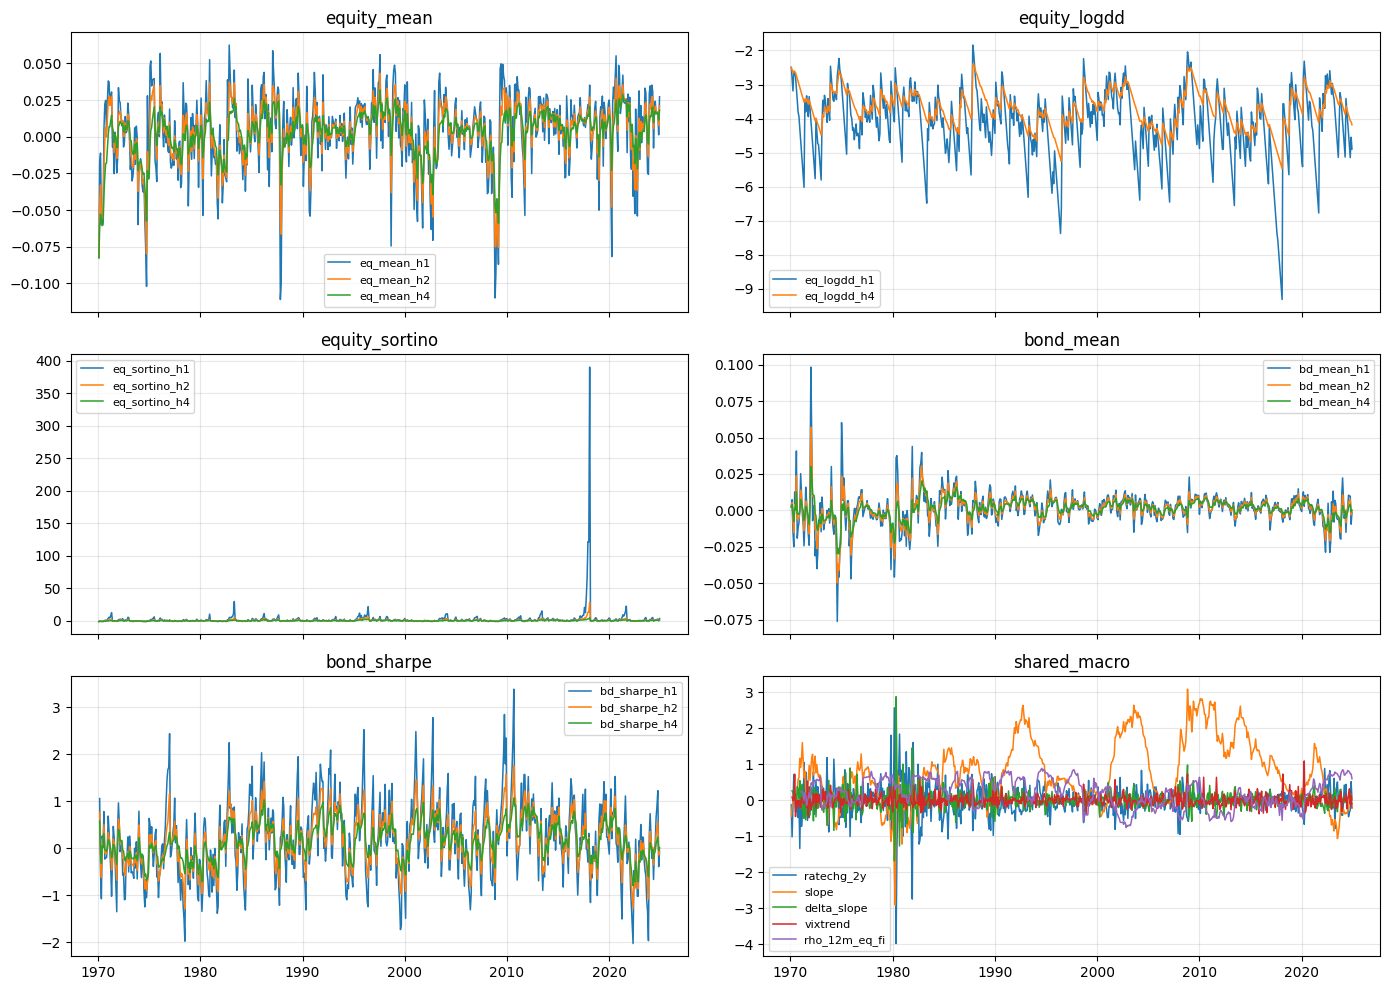

In [73]:
feature_check_rows = []
for col in final_feature_cols:
    s = pd.to_numeric(feature_panel[col], errors="coerce")
    valid_idx = feature_panel.index[s.notna()]
    feature_check_rows.append(
        {
            "column": col,
            "missing_share": float(s.isna().mean()),
            "first_valid_date": None if len(valid_idx) == 0 else str(feature_panel.loc[valid_idx.min(), "date"].date()),
            "last_valid_date": None if len(valid_idx) == 0 else str(feature_panel.loc[valid_idx.max(), "date"].date()),
        }
    )

feature_check_df = pd.DataFrame(feature_check_rows)

print("FINAL_FEATURE_CHECKS")
print(feature_check_df.to_string(index=False))
print()
print("FINAL_FEATURE_PANEL_TAIL")
print(feature_panel[["date"] + equity_final_features + bond_final_features].tail(10).to_string(index=False))

import matplotlib.pyplot as plt

plot_groups = {
    "equity_mean": ["eq_mean_h1", "eq_mean_h2", "eq_mean_h4"],
    "equity_logdd": ["eq_logdd_h1", "eq_logdd_h4"],
    "equity_sortino": ["eq_sortino_h1", "eq_sortino_h2", "eq_sortino_h4"],
    "bond_mean": ["bd_mean_h1", "bd_mean_h2", "bd_mean_h4"],
    "bond_sharpe": ["bd_sharpe_h1", "bd_sharpe_h2", "bd_sharpe_h4"],
    "shared_macro": ["ratechg_2y", "slope", "delta_slope", "vixtrend", "rho_12m_eq_fi"],
}

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for ax, (group_name, cols) in zip(axes, plot_groups.items()):
    cols = [col for col in cols if col in feature_panel.columns]
    for col in cols:
        ax.plot(feature_panel["date"], feature_panel[col], label=col, linewidth=1.1)
    ax.set_title(group_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

for ax in axes[len(plot_groups):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Jump-model regime identification


In [74]:
from sklearn.preprocessing import StandardScaler
from jumpmodels.jump import JumpModel


In [75]:
LAMBDA_GRID = [0.0, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]
RANDOM_STATE = 42

jm_equity_cols = [
    "eq_logdd_h1",
    "eq_logdd_h4",
    "eq_mean_h1",
    "eq_mean_h2",
    "eq_mean_h4",
    "eq_sortino_h1",
    "eq_sortino_h2",
    "eq_sortino_h4",
]

jm_bond_cols = [
    "bd_mean_h1",
    "bd_mean_h2",
    "bd_mean_h4",
    "bd_sharpe_h1",
    "bd_sharpe_h2",
    "bd_sharpe_h4",
]

print("JM_FEATURES")
print("Equity")
print(pd.DataFrame({"feature": jm_equity_cols}).to_string(index=False))
print()
print("Bond")
print(pd.DataFrame({"feature": jm_bond_cols}).to_string(index=False))
print()
print("LAMBDA_GRID")
print(pd.DataFrame({"lambda": LAMBDA_GRID}).to_string(index=False))


JM_FEATURES
Equity
      feature
  eq_logdd_h1
  eq_logdd_h4
   eq_mean_h1
   eq_mean_h2
   eq_mean_h4
eq_sortino_h1
eq_sortino_h2
eq_sortino_h4

Bond
     feature
  bd_mean_h1
  bd_mean_h2
  bd_mean_h4
bd_sharpe_h1
bd_sharpe_h2
bd_sharpe_h4

LAMBDA_GRID
    lambda
  0.000000
  0.001000
  0.003000
  0.010000
  0.030000
  0.100000
  0.300000
  1.000000
  3.000000
 10.000000
 30.000000
100.000000


In [76]:
def run_lengths_from_binary(state_bull):
    s = pd.Series(state_bull).astype(int).reset_index(drop=True)
    runs = []
    current = int(s.iloc[0])
    length = 1
    for val in s.iloc[1:]:
        val = int(val)
        if val == current:
            length += 1
        else:
            runs.append({"state": current, "run_length": length})
            current = val
            length = 1
    runs.append({"state": current, "run_length": length})
    return pd.DataFrame(runs)

def transition_probs_from_binary(state_bull):
    s = pd.Series(state_bull).astype(int).reset_index(drop=True)
    counts = np.zeros((2, 2), dtype=float)
    for a, b in zip(s.iloc[:-1], s.iloc[1:]):
        counts[int(a), int(b)] += 1.0
    probs = np.full((2, 2), np.nan, dtype=float)
    for i in range(2):
        row_sum = counts[i].sum()
        if row_sum > 0:
            probs[i, :] = counts[i, :] / row_sum
    return probs

def fit_jm_grid(asset, df, excess_col, feature_cols, lambda_grid):
    fit_df = df.loc[df[[excess_col] + feature_cols].notna().all(axis=1), ["date", excess_col] + feature_cols].copy()
    fit_df = fit_df.reset_index(drop=True)

    X_raw = fit_df[feature_cols].copy()
    X_fit = pd.DataFrame(
        StandardScaler().fit_transform(X_raw),
        index=fit_df.index,
        columns=feature_cols,
    )

    diagnostics = []
    labels = []

    for lam in lambda_grid:
        jm = JumpModel(
            n_components=2,
            jump_penalty=float(lam),
            cont=False,
            random_state=RANDOM_STATE,
            max_iter=1000,
            tol=1e-8,
            n_init=20,
            verbose=0,
        )
        jm.fit(X_fit, ret_ser=fit_df[excess_col], sort_by="cumret")

        raw_state = pd.Series(np.asarray(jm.labels_).astype(int), index=fit_df.index)
        cumret_by_state = fit_df.groupby(raw_state)[excess_col].sum().sort_index()
        bull_state_id = int(cumret_by_state.idxmax())
        bear_state_id = int(cumret_by_state.idxmin())
        state_bull = (raw_state == bull_state_id).astype(int)

        if bull_state_id == 0:
            p_bull = np.asarray(jm.proba_)[:, 0]
            p_bear = np.asarray(jm.proba_)[:, 1]
        else:
            p_bull = np.asarray(jm.proba_)[:, 1]
            p_bear = np.asarray(jm.proba_)[:, 0]

        n_switches = int(state_bull.ne(state_bull.shift(1)).iloc[1:].sum())
        runs = run_lengths_from_binary(state_bull)
        trans = transition_probs_from_binary(state_bull)
        bull_mask = state_bull == 1
        bear_mask = state_bull == 0
        bull_share = float(bull_mask.mean())
        bear_share = float(bear_mask.mean())

        diagnostics.append(
            {
                "asset": asset,
                "lambda": float(lam),
                "n_obs": int(len(fit_df)),
                "bull_share": bull_share,
                "bear_share": bear_share,
                "n_switches": n_switches,
                "trans_bear_to_bear": float(trans[0, 0]),
                "trans_bear_to_bull": float(trans[0, 1]),
                "trans_bull_to_bear": float(trans[1, 0]),
                "trans_bull_to_bull": float(trans[1, 1]),
                "avg_run_length": float(runs["run_length"].mean()),
                "bull_mean_excess": float(fit_df.loc[bull_mask, excess_col].mean()),
                "bear_mean_excess": float(fit_df.loc[bear_mask, excess_col].mean()),
                "bull_n_months": int(bull_mask.sum()),
                "bear_n_months": int(bear_mask.sum()),
            }
        )

        labels.append(
            pd.DataFrame(
                {
                    "date": fit_df["date"],
                    "asset": asset,
                    "lambda": float(lam),
                    "raw_state": raw_state.to_numpy(dtype=int),
                    "state_bull": state_bull.to_numpy(dtype=int),
                    "state_bear": (1 - state_bull).to_numpy(dtype=int),
                    "p_bull": np.asarray(p_bull, dtype=float),
                    "p_bear": np.asarray(p_bear, dtype=float),
                    "excess_return": fit_df[excess_col].to_numpy(dtype=float),
                }
            )
        )

    diagnostics_df = pd.DataFrame(diagnostics)
    labels_df = pd.concat(labels, axis=0, ignore_index=True)
    return diagnostics_df, labels_df


In [77]:
jm_equity_diag, jm_equity_labels = fit_jm_grid(
    asset="equity",
    df=feature_panel,
    excess_col="equity_excess",
    feature_cols=jm_equity_cols,
    lambda_grid=LAMBDA_GRID,
)

jm_bond_diag, jm_bond_labels = fit_jm_grid(
    asset="bond",
    df=feature_panel,
    excess_col="bond_excess",
    feature_cols=jm_bond_cols,
    lambda_grid=LAMBDA_GRID,
)

jm_diagnostics = pd.concat([jm_bond_diag, jm_equity_diag], axis=0, ignore_index=True)
jm_diagnostics = jm_diagnostics.sort_values(["asset", "lambda"]).reset_index(drop=True)

jm_labels = pd.concat([jm_bond_labels, jm_equity_labels], axis=0, ignore_index=True)
jm_labels = jm_labels.sort_values(["asset", "lambda", "date"]).reset_index(drop=True)

print("JM_DIAGNOSTICS_SUMMARY")
print(
    pd.DataFrame(
        {
            "item": ["n_rows_diag", "n_rows_labels", "start_date", "end_date"],
            "value": [
                len(jm_diagnostics),
                len(jm_labels),
                str(jm_labels["date"].min().date()),
                str(jm_labels["date"].max().date()),
            ],
        }
    ).to_string(index=False)
)


JM_DIAGNOSTICS_SUMMARY
         item      value
  n_rows_diag         24
n_rows_labels      15804
   start_date 1970-01-31
     end_date 2024-11-30


In [78]:
bond_lambda_table = jm_diagnostics.loc[jm_diagnostics["asset"] == "bond", [
    "lambda",
    "bull_share",
    "bear_share",
    "n_switches",
    "trans_bear_to_bear",
    "trans_bear_to_bull",
    "trans_bull_to_bear",
    "trans_bull_to_bull",
    "avg_run_length",
    "bull_mean_excess",
    "bear_mean_excess",
]].copy()

equity_lambda_table = jm_diagnostics.loc[jm_diagnostics["asset"] == "equity", [
    "lambda",
    "bull_share",
    "bear_share",
    "n_switches",
    "trans_bear_to_bear",
    "trans_bear_to_bull",
    "trans_bull_to_bear",
    "trans_bull_to_bull",
    "avg_run_length",
    "bull_mean_excess",
    "bear_mean_excess",
]].copy()

bond_lambda_table["balance"] = (
    (100 * bond_lambda_table["bull_share"]).round(1).astype(str)
    + "/"
    + (100 * bond_lambda_table["bear_share"]).round(1).astype(str)
)
equity_lambda_table["balance"] = (
    (100 * equity_lambda_table["bull_share"]).round(1).astype(str)
    + "/"
    + (100 * equity_lambda_table["bear_share"]).round(1).astype(str)
)

print("LAMBDA_SCREEN_BOND")
print(
    bond_lambda_table[[
        "lambda",
        "balance",
        "n_switches",
        "trans_bear_to_bear",
        "trans_bear_to_bull",
        "trans_bull_to_bear",
        "trans_bull_to_bull",
        "avg_run_length",
        "bull_mean_excess",
        "bear_mean_excess",
    ]].to_string(index=False)
)
print()
print("LAMBDA_SCREEN_EQUITY")
print(
    equity_lambda_table[[
        "lambda",
        "balance",
        "n_switches",
        "trans_bear_to_bear",
        "trans_bear_to_bull",
        "trans_bull_to_bear",
        "trans_bull_to_bull",
        "avg_run_length",
        "bull_mean_excess",
        "bear_mean_excess",
    ]].to_string(index=False)
)


LAMBDA_SCREEN_BOND
    lambda   balance  n_switches  trans_bear_to_bear  trans_bear_to_bull  trans_bull_to_bear  trans_bull_to_bull  avg_run_length  bull_mean_excess  bear_mean_excess
  0.000000 57.3/42.7         119            0.789286            0.210714            0.159151            0.840849        5.483333          0.009289         -0.009652
  0.001000 57.3/42.7         119            0.789286            0.210714            0.159151            0.840849        5.483333          0.009289         -0.009652
  0.003000 57.3/42.7         119            0.789286            0.210714            0.159151            0.840849        5.483333          0.009289         -0.009652
  0.010000 57.9/42.1         115            0.793478            0.206522            0.152231            0.847769        5.672414          0.009097         -0.009661
  0.030000 57.8/42.2         113            0.797834            0.202166            0.150000            0.850000        5.771930          0.009114         -

In [79]:
BOND_LAMBDA_SELECTED = 3.0
EQUITY_LAMBDA_SELECTED = 10.0

bond_state_path = jm_labels.loc[
    (jm_labels["asset"] == "bond") & (jm_labels["lambda"] == BOND_LAMBDA_SELECTED),
    ["date", "asset", "lambda", "state_bull", "state_bear", "p_bull", "p_bear", "excess_return"],
].copy().reset_index(drop=True)

equity_state_path = jm_labels.loc[
    (jm_labels["asset"] == "equity") & (jm_labels["lambda"] == EQUITY_LAMBDA_SELECTED),
    ["date", "asset", "lambda", "state_bull", "state_bear", "p_bull", "p_bear", "excess_return"],
].copy().reset_index(drop=True)

selected_state_paths = pd.concat([bond_state_path, equity_state_path], axis=0, ignore_index=True)

chosen_lambda_summary = jm_diagnostics.loc[
    ((jm_diagnostics["asset"] == "bond") & (jm_diagnostics["lambda"] == BOND_LAMBDA_SELECTED))
    | ((jm_diagnostics["asset"] == "equity") & (jm_diagnostics["lambda"] == EQUITY_LAMBDA_SELECTED)),
    [
        "asset",
        "lambda",
        "bull_share",
        "bear_share",
        "n_switches",
        "avg_run_length",
        "bull_mean_excess",
        "bear_mean_excess",
    ],
].copy().reset_index(drop=True)

print("CHOSEN_LAMBDAS")
print(pd.DataFrame({"asset": ["bond", "equity"], "lambda": [BOND_LAMBDA_SELECTED, EQUITY_LAMBDA_SELECTED]}).to_string(index=False))
print()
print("CHOSEN_LAMBDA_SUMMARY")
print(chosen_lambda_summary.to_string(index=False))
print()
print("SELECTED_STATE_PATHS_TAIL")
print(selected_state_paths.groupby("asset").tail(12).to_string(index=False))


CHOSEN_LAMBDAS
 asset    lambda
  bond  3.000000
equity 10.000000

CHOSEN_LAMBDA_SUMMARY
 asset    lambda  bull_share  bear_share  n_switches  avg_run_length  bull_mean_excess  bear_mean_excess
  bond  3.000000    0.598784    0.401216          59       10.966667          0.007754         -0.008580
equity 10.000000    0.778452    0.221548          19       32.950000          0.011059         -0.022022

SELECTED_STATE_PATHS_TAIL
      date  asset    lambda  state_bull  state_bear   p_bull   p_bear  excess_return
2023-12-31   bond  3.000000           1           0 1.000000 0.000000       0.033980
2024-01-31   bond  3.000000           1           0 1.000000 0.000000      -0.007447
2024-02-29   bond  3.000000           0           1 0.000000 1.000000      -0.018328
2024-03-31   bond  3.000000           0           1 0.000000 1.000000       0.004935
2024-04-30   bond  3.000000           0           1 0.000000 1.000000      -0.029961
2024-05-31   bond  3.000000           0           1 0.00000

## Carry-forward baseline and chosen-regime view


In [80]:
def safe_mean(x):
    s = pd.Series(x).dropna().astype(float)
    return np.nan if len(s) == 0 else float(s.mean())

def safe_std(x):
    s = pd.Series(x).dropna().astype(float)
    return np.nan if len(s) == 0 else float(s.std(ddof=0))

def safe_sharpe(x):
    s = pd.Series(x).dropna().astype(float)
    if len(s) < 2:
        return np.nan
    vol = float(s.std(ddof=0))
    if vol <= 1e-12:
        return np.nan
    return float(np.sqrt(12.0) * s.mean() / vol)

def binary_stats(actual, pred):
    a = pd.Series(actual).astype(float)
    p = pd.Series(pred).astype(float)
    mask = a.notna() & p.notna()
    a = a.loc[mask].astype(int)
    p = p.loc[mask].astype(int)

    tp = int(((p == 1) & (a == 1)).sum())
    tn = int(((p == 0) & (a == 0)).sum())
    fp = int(((p == 1) & (a == 0)).sum())
    fn = int(((p == 0) & (a == 1)).sum())

    n = len(a)
    acc = np.nan if n == 0 else (tp + tn) / n
    rec = np.nan if (tp + fn) == 0 else tp / (tp + fn)
    spec = np.nan if (tn + fp) == 0 else tn / (tn + fp)
    bal = np.nanmean([rec, spec])

    return {
        "n_eval_months": int(n),
        "next_state_accuracy": float(acc) if pd.notna(acc) else np.nan,
        "balanced_accuracy": float(bal) if pd.notna(bal) else np.nan,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


In [81]:
forward_long = pd.concat(
    [
        panel[["date", "sp500_fwd_excess_1m"]].rename(columns={"sp500_fwd_excess_1m": "fwd_excess_1m"}).assign(asset="equity"),
        panel[["date", "bond_fwd_excess_1m"]].rename(columns={"bond_fwd_excess_1m": "fwd_excess_1m"}).assign(asset="bond"),
    ],
    axis=0,
    ignore_index=True,
).sort_values(["asset", "date"]).reset_index(drop=True)

carry_eval = jm_labels.merge(forward_long, on=["date", "asset"], how="left")
carry_eval = carry_eval.sort_values(["asset", "lambda", "date"]).reset_index(drop=True)

carry_eval["target_next_state_bull"] = carry_eval.groupby(["asset", "lambda"])["state_bull"].shift(-1)
carry_eval["pred_next_state_bull"] = carry_eval["state_bull"].astype(float)
carry_eval["strategy_excess_01"] = carry_eval["pred_next_state_bull"] * carry_eval["fwd_excess_1m"]
carry_eval["always_in_excess"] = carry_eval["fwd_excess_1m"]


In [82]:
carry_rows = []
for (asset, lam), g in carry_eval.groupby(["asset", "lambda"], sort=True):
    valid = g.loc[g["target_next_state_bull"].notna() & g["fwd_excess_1m"].notna()].copy()
    cls = binary_stats(valid["target_next_state_bull"], valid["pred_next_state_bull"])

    carry_rows.append(
        {
            "asset": asset,
            "lambda": float(lam),
            "n_eval_months": cls["n_eval_months"],
            "next_state_accuracy": cls["next_state_accuracy"],
            "balanced_accuracy": cls["balanced_accuracy"],
            "mean_excess_return": safe_mean(valid["strategy_excess_01"]),
            "volatility": safe_std(valid["strategy_excess_01"]),
            "ann_sharpe": safe_sharpe(valid["strategy_excess_01"]),
            "investment_frequency": float(valid["pred_next_state_bull"].mean()) if len(valid) else np.nan,
        }
    )

carry_summary = pd.DataFrame(carry_rows).sort_values(["asset", "lambda"]).reset_index(drop=True)

lambda_comparison = jm_diagnostics.merge(carry_summary, on=["asset", "lambda"], how="left")

lambda_comparison["balance"] = (
    (100 * lambda_comparison["bull_share"]).round(1).astype(str)
    + "/"
    + (100 * lambda_comparison["bear_share"]).round(1).astype(str)
)
lambda_comparison["transition_probs"] = lambda_comparison.apply(
    lambda r: "["
    + f"{r['trans_bear_to_bear']:.3f}, {r['trans_bear_to_bull']:.3f}, {r['trans_bull_to_bear']:.3f}, {r['trans_bull_to_bull']:.3f}"
    + "]",
    axis=1,
)
lambda_comparison["bull_vs_bear_excess"] = lambda_comparison.apply(
    lambda r: f"{r['bull_mean_excess']:.4f} vs {r['bear_mean_excess']:.4f} (sep={(r['bull_mean_excess'] - r['bear_mean_excess']):.4f})",
    axis=1,
)

print("JM_LAMBDA_COMPARISON_TABLE")
print(
    lambda_comparison[[
        "asset",
        "lambda",
        "balance",
        "n_switches",
        "transition_probs",
        "avg_run_length",
        "bull_vs_bear_excess",
        "next_state_accuracy",
        "balanced_accuracy",
        "mean_excess_return",
        "volatility",
        "ann_sharpe",
        "investment_frequency",
    ]].to_string(index=False)
)

JM_LAMBDA_COMPARISON_TABLE
 asset     lambda   balance  n_switches             transition_probs  avg_run_length            bull_vs_bear_excess  next_state_accuracy  balanced_accuracy  mean_excess_return  volatility  ann_sharpe  investment_frequency
  bond   0.000000 57.3/42.7         119 [0.789, 0.211, 0.159, 0.841]        5.483333 0.0093 vs -0.0097 (sep=0.0189)             0.825939           0.817218            0.002109    0.010298    0.709308              0.609215
  bond   0.001000 57.3/42.7         119 [0.789, 0.211, 0.159, 0.841]        5.483333 0.0093 vs -0.0097 (sep=0.0189)             0.825939           0.817218            0.002109    0.010298    0.709308              0.609215
  bond   0.003000 57.3/42.7         119 [0.789, 0.211, 0.159, 0.841]        5.483333 0.0093 vs -0.0097 (sep=0.0189)             0.825939           0.817218            0.002109    0.010298    0.709308              0.609215
  bond   0.010000 57.9/42.1         115 [0.793, 0.207, 0.152, 0.848]        5.672414 

In [83]:
#chosen_lambda_table = (
#    lambda_comparison.loc[lambda_comparison["candidate_moderate"]]
#    .sort_values(["asset", "ann_sharpe", "balanced_accuracy", "lambda"], ascending=[True, False, False, True])
#    .groupby("asset", as_index=False)
#    .head(1)
#    .reset_index(drop=True)
#)
#
#chosen_lambda_map = dict(zip(chosen_lambda_table["asset"], chosen_lambda_table["lambda"]))
#BOND_LAMBDA_SELECTED = float(chosen_lambda_map["bond"])
#EQUITY_LAMBDA_SELECTED = float(chosen_lambda_map["equity"])
#
#selected_state_paths = jm_labels.loc[
#    ((jm_labels["asset"] == "bond") & (jm_labels["lambda"] == BOND_LAMBDA_SELECTED))
#    | ((jm_labels["asset"] == "equity") & (jm_labels["lambda"] == EQUITY_LAMBDA_SELECTED)),
#    ["date", "asset", "lambda", "state_bull", "state_bear", "p_bull", "p_bear", "excess_return"],
#].copy().sort_values(["asset", "date"]).reset_index(drop=True)
#
#print("CHOSEN_LAMBDAS")
#print(pd.DataFrame({"asset": ["bond", "equity"], "lambda": [BOND_LAMBDA_SELECTED, EQUITY_LAMBDA_SELECTED]}).to_string(index=False))
#print()
#print("CHOSEN_LAMBDA_SUMMARY")
#print(
#    chosen_lambda_table[[
#        "asset",
#        "lambda",
#        "balance",
#        "n_switches",
#        "avg_run_length",
#        "next_state_accuracy",
#        "balanced_accuracy",
#        "ann_sharpe",
#        "investment_frequency",
#    ]].to_string(index=False)
#)
#print()
#print("SELECTED_STATE_PATHS_TAIL")
#print(selected_state_paths.groupby("asset").tail(12).to_string(index=False))


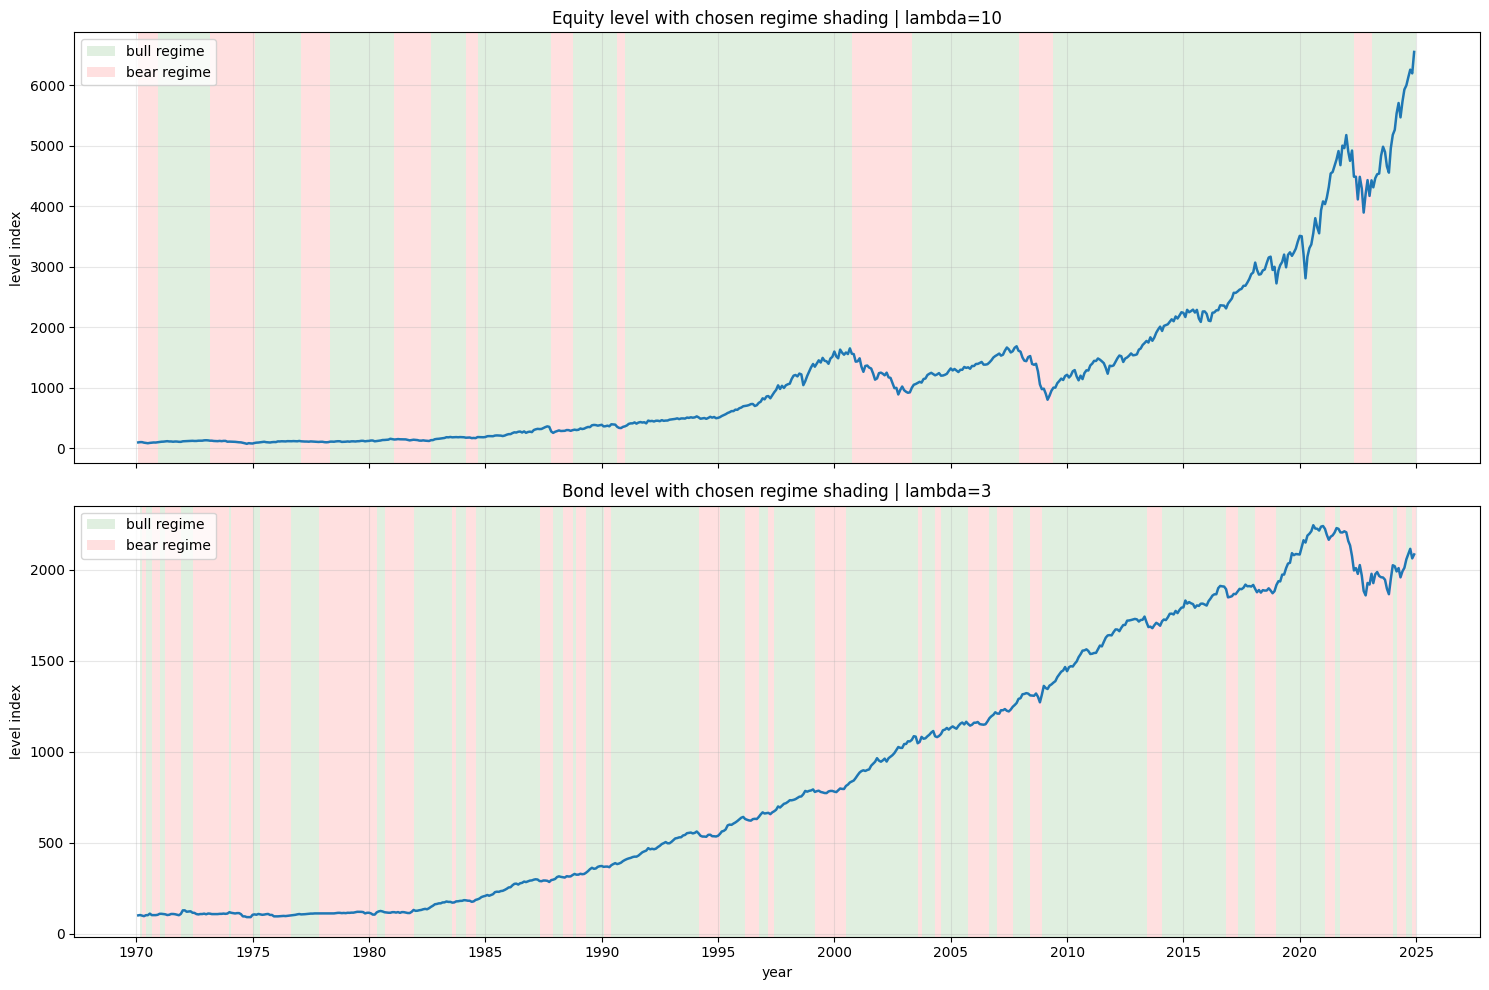

In [84]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

plot_df = panel[["date", "sprtrn_sp500", "agg_ret"]].copy()
plot_df["equity_level"] = 100.0 * (1.0 + plot_df["sprtrn_sp500"]).cumprod()
plot_df["bond_level"] = 100.0 * (1.0 + plot_df["agg_ret"]).cumprod()

def contiguous_spans(date_series, state_series):
    d = pd.DataFrame({"date": pd.to_datetime(date_series), "state": pd.Series(state_series).astype(float)}).dropna().reset_index(drop=True)
    spans = []
    start = d.loc[0, "date"]
    prev_date = d.loc[0, "date"]
    current = int(d.loc[0, "state"])
    for i in range(1, len(d)):
        dt = d.loc[i, "date"]
        st = int(d.loc[i, "state"])
        if st != current:
            spans.append((start, prev_date, current))
            start = dt
            current = st
        prev_date = dt
    spans.append((start, prev_date, current))
    return spans

def add_regime_shading(ax, regime_df):
    for start, end, state in contiguous_spans(regime_df["date"], regime_df["state_bull"]):
        ax.axvspan(start, end + pd.offsets.MonthEnd(1), color=("green" if state == 1 else "red"), alpha=0.12, lw=0)

eq_reg = selected_state_paths.loc[selected_state_paths["asset"] == "equity", ["date", "state_bull"]].copy()
bd_reg = selected_state_paths.loc[selected_state_paths["asset"] == "bond", ["date", "state_bull"]].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

axes[0].plot(plot_df["date"], plot_df["equity_level"], linewidth=1.8)
add_regime_shading(axes[0], eq_reg)
axes[0].set_title(f"Equity level with chosen regime shading | lambda={EQUITY_LAMBDA_SELECTED:g}")
axes[0].set_ylabel("level index")
axes[0].grid(True, alpha=0.3)

axes[1].plot(plot_df["date"], plot_df["bond_level"], linewidth=1.8)
add_regime_shading(axes[1], bd_reg)
axes[1].set_title(f"Bond level with chosen regime shading | lambda={BOND_LAMBDA_SELECTED:g}")
axes[1].set_ylabel("level index")
axes[1].set_xlabel("year")
axes[1].grid(True, alpha=0.3)

legend_handles = [
    Patch(facecolor="green", alpha=0.12, edgecolor="none", label="bull regime"),
    Patch(facecolor="red", alpha=0.12, edgecolor="none", label="bear regime"),
]
axes[0].legend(handles=legend_handles, loc="upper left")
axes[1].legend(handles=legend_handles, loc="upper left")

axes[1].xaxis.set_major_locator(mdates.YearLocator(base=5))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


## Supervised regime forecasting


In [85]:
import json
import importlib
import importlib.metadata as importlib_metadata
from xgboost import XGBClassifier


TRAIN_MONTHS = 11 * 12
VALID_MONTHS = 5 * 12
UPDATE_BLOCK_MONTHS = 6
PROBA_THRESHOLD = 0.50
RANDOM_STATE = 42
N_JOBS = -1
SMOOTH_HALFLIFE_GRID = [0, 1, 2, 3]

XGB_PARAM_GRID = [
    {"n_estimators": 100, "max_depth": 2, "learning_rate": 0.05, "min_child_weight": 5, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0},
    {"n_estimators": 200, "max_depth": 2, "learning_rate": 0.05, "min_child_weight": 5, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0},
    {"n_estimators": 200, "max_depth": 3, "learning_rate": 0.05, "min_child_weight": 5, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.03, "min_child_weight": 10, "subsample": 1.0, "colsample_bytree": 1.0, "reg_lambda": 1.0},
    {"n_estimators": 300, "max_depth": 3, "learning_rate": 0.03, "min_child_weight": 10, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 2.0},
    {"n_estimators": 500, "max_depth": 2, "learning_rate": 0.02, "min_child_weight": 10, "subsample": 0.8, "colsample_bytree": 0.8, "reg_lambda": 2.0},
]

DESIRED_REDUCED_LAMBDAS = [0.1, 0.3, 1.0, 3.0, 10.0]
FINAL_LAMBDA_MAP = {"bond": 3.0, "equity": 10.0}
XGBOOST_VERSION = importlib_metadata.version("xgboost")


print("FORECAST_RUN_CONTROL")
print(
    pd.DataFrame(
        {
            "setting": [
                "TRAIN_MONTHS",
                "VALID_MONTHS",
                "UPDATE_BLOCK_MONTHS",
                "PROBA_THRESHOLD",
                "SMOOTH_HALFLIFE_GRID",
                "N_LAMBDAS",
                "XGB_GRID_SIZE",
                "RANDOM_STATE",
                "xgboost_version",
            ],
            "value": [
                TRAIN_MONTHS,
                VALID_MONTHS,
                UPDATE_BLOCK_MONTHS,
                PROBA_THRESHOLD,
                str(SMOOTH_HALFLIFE_GRID),
                len(DESIRED_REDUCED_LAMBDAS),
                len(XGB_PARAM_GRID),
                RANDOM_STATE,
                XGBOOST_VERSION,
            ],
        }
    ).to_string(index=False)
)


FORECAST_RUN_CONTROL
             setting        value
        TRAIN_MONTHS          132
        VALID_MONTHS           60
 UPDATE_BLOCK_MONTHS            6
     PROBA_THRESHOLD     0.500000
SMOOTH_HALFLIFE_GRID [0, 1, 2, 3]
           N_LAMBDAS            5
       XGB_GRID_SIZE            6
        RANDOM_STATE           42
     xgboost_version        3.2.0


In [86]:
equity_predictor_cols = [
    "eq_logdd_h1",
    "eq_logdd_h4",
    "eq_mean_h1",
    "eq_mean_h2",
    "eq_mean_h4",
    "eq_sortino_h1",
    "eq_sortino_h2",
    "eq_sortino_h4",
    "ratechg_2y",
    "slope",
    "delta_slope",
    "vixtrend",
    "rho_12m_eq_fi",
]

bond_predictor_cols = [
    "bd_mean_h1",
    "bd_mean_h2",
    "bd_mean_h4",
    "bd_sharpe_h1",
    "bd_sharpe_h2",
    "bd_sharpe_h4",
    "ratechg_2y",
    "slope",
    "delta_slope",
    "vixtrend",
    "rho_12m_eq_fi",
]

feature_panel_equity = feature_panel[["date"] + equity_predictor_cols].copy()
feature_panel_bond = feature_panel[["date"] + bond_predictor_cols].copy()

feature_panel_map = {
    "equity": feature_panel_equity,
    "bond": feature_panel_bond,
}

predictor_cols_map = {
    "equity": equity_predictor_cols,
    "bond": bond_predictor_cols,
}

forward_col_map = {
    "equity": "sp500_fwd_excess_1m",
    "bond": "bond_fwd_excess_1m",
}

required_lambda_rows = []
for asset_name in ["equity", "bond"]:
    candidate_lambdas = (
        lambda_comparison.loc[
            (lambda_comparison["asset"] == asset_name)
            & (lambda_comparison["lambda"].isin(DESIRED_REDUCED_LAMBDAS)),
            "lambda",
        ]
        .sort_values()
        .astype(float)
        .tolist()
    )
    if candidate_lambdas != DESIRED_REDUCED_LAMBDAS:
        raise ValueError(f"{asset_name}: reduced candidate lambda set mismatch. Got {candidate_lambdas}")
    required_lambda_rows.append({"asset": asset_name, "candidate_lambdas": str(candidate_lambdas)})

input_check_rows = []
for asset_name in ["equity", "bond"]:
    for lam in DESIRED_REDUCED_LAMBDAS:
        target_panel = (
            jm_labels.loc[(jm_labels["asset"] == asset_name) & (jm_labels["lambda"] == lam), ["date", "state_bull"]]
            .sort_values("date")
            .reset_index(drop=True)
        )
        target_panel["target_next_state_bull"] = target_panel["state_bull"].shift(-1)
        eligible = target_panel.merge(
            panel[["date", forward_col_map[asset_name]]].rename(columns={forward_col_map[asset_name]: "realized_fwd_excess_1m"}),
            on="date",
            how="left",
            validate="one_to_one",
        )
        eligible = eligible.loc[eligible["target_next_state_bull"].notna() & eligible["realized_fwd_excess_1m"].notna()].copy()
        input_check_rows.append(
            {
                "asset": asset_name,
                "lambda": float(lam),
                "n_eligible_rows": int(len(eligible)),
                "first_eligible_date": None if len(eligible) == 0 else str(eligible["date"].min().date()),
                "last_eligible_date": None if len(eligible) == 0 else str(eligible["date"].max().date()),
            }
        )

print("FORECAST_INPUT_CHECK")
print(pd.DataFrame(required_lambda_rows).to_string(index=False))
print()
print(pd.DataFrame(input_check_rows).to_string(index=False))


FORECAST_INPUT_CHECK
 asset          candidate_lambdas
equity [0.1, 0.3, 1.0, 3.0, 10.0]
  bond [0.1, 0.3, 1.0, 3.0, 10.0]

 asset    lambda  n_eligible_rows first_eligible_date last_eligible_date
equity  0.100000              658          1970-01-31         2024-10-31
equity  0.300000              658          1970-01-31         2024-10-31
equity  1.000000              658          1970-01-31         2024-10-31
equity  3.000000              658          1970-01-31         2024-10-31
equity 10.000000              658          1970-01-31         2024-10-31
  bond  0.100000              586          1976-01-31         2024-10-31
  bond  0.300000              586          1976-01-31         2024-10-31
  bond  1.000000              586          1976-01-31         2024-10-31
  bond  3.000000              586          1976-01-31         2024-10-31
  bond 10.000000              586          1976-01-31         2024-10-31


In [87]:
def safe_mean(x):
    s = pd.Series(x).dropna().astype("float64")
    return np.nan if len(s) == 0 else float(s.mean())

def safe_std(x):
    s = pd.Series(x).dropna().astype("float64")
    return np.nan if len(s) == 0 else float(s.std(ddof=0))

def safe_sharpe(x, annualize=True):
    s = pd.Series(x).dropna().astype("float64")
    if len(s) < 2:
        return np.nan
    vol = float(s.std(ddof=0))
    if (not np.isfinite(vol)) or (vol <= 1e-12):
        return np.nan
    out = float(s.mean()) / vol
    if annualize:
        out *= np.sqrt(12.0)
    return float(out)

def binary_classification_stats(actual, pred):
    a = pd.Series(actual).astype("float64")
    p = pd.Series(pred).astype("float64")
    mask = a.notna() & p.notna()
    a = a.loc[mask].astype("int64")
    p = p.loc[mask].astype("int64")
    n = len(a)
    if n == 0:
        return {
            "n_eval": 0,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "precision_bull": np.nan,
            "recall_bull": np.nan,
            "specificity_bear": np.nan,
            "tp": 0,
            "tn": 0,
            "fp": 0,
            "fn": 0,
        }
    tp = int(((p == 1) & (a == 1)).sum())
    tn = int(((p == 0) & (a == 0)).sum())
    fp = int(((p == 1) & (a == 0)).sum())
    fn = int(((p == 0) & (a == 1)).sum())
    accuracy = (tp + tn) / n
    recall_bull = np.nan if (tp + fn) == 0 else tp / (tp + fn)
    specificity_bear = np.nan if (tn + fp) == 0 else tn / (tn + fp)
    balanced_accuracy = np.nanmean([recall_bull, specificity_bear])
    precision_bull = np.nan if (tp + fp) == 0 else tp / (tp + fp)
    return {
        "n_eval": int(n),
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_accuracy),
        "precision_bull": float(precision_bull) if np.isfinite(precision_bull) else np.nan,
        "recall_bull": float(recall_bull) if np.isfinite(recall_bull) else np.nan,
        "specificity_bear": float(specificity_bear) if np.isfinite(specificity_bear) else np.nan,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }

def fit_constant_model(prob):
    return {
        "model_type": "constant",
        "constant_prob": float(prob),
        "params": {"model_type": "constant", "constant_prob": float(prob)},
        "smoothing_halflife": 0.0,
    }

def predict_prob(model_info, X):
    if model_info["model_type"] == "constant":
        return np.repeat(float(model_info["constant_prob"]), len(X)).astype("float64")
    return model_info["model"].predict_proba(X)[:, 1].astype("float64")

def smooth_probability_series(prob_array, halflife_months):
    prob = pd.Series(np.asarray(prob_array, dtype="float64"))
    if halflife_months in [0, 0.0, None]:
        return prob.to_numpy(dtype="float64")
    return prob.ewm(halflife=float(halflife_months), adjust=False, min_periods=1).mean().to_numpy(dtype="float64")

def validation_score_tuple(strategy_sharpe, bal_acc, mean_excess, halflife_months, params):
    s1 = -1e18 if not np.isfinite(strategy_sharpe) else float(strategy_sharpe)
    s2 = -1e18 if not np.isfinite(bal_acc) else float(bal_acc)
    s3 = -1e18 if not np.isfinite(mean_excess) else float(mean_excess)
    complexity_penalty = -float(params.get("max_depth", 0) * 10000 + params.get("n_estimators", 0))
    smoothing_penalty = -float(halflife_months if halflife_months is not None else 0.0)
    return (s1, s2, s3, complexity_penalty, smoothing_penalty)

def select_best_xgb_model(train_df, val_df, feature_cols, param_grid, smoothing_halflife_grid):
    y_train = train_df["target_next_state_bull"].astype("int64").to_numpy()
    y_val = val_df["target_next_state_bull"].astype("int64").to_numpy()
    X_train = train_df[feature_cols]
    X_val = val_df[feature_cols]
    val_returns = val_df["realized_fwd_excess_1m"].to_numpy(dtype="float64")

    if len(np.unique(y_train)) < 2:
        model_info = fit_constant_model(float(np.mean(y_train)) if len(y_train) else 0.5)
        raw_val_prob = predict_prob(model_info, X_val)
        smooth_val_prob = smooth_probability_series(raw_val_prob, 0.0)
        smooth_val_pred = (smooth_val_prob >= PROBA_THRESHOLD).astype("int64")
        smooth_val_strategy = smooth_val_pred * val_returns
        cls = binary_classification_stats(y_val, smooth_val_pred)
        metrics = {
            "selected_val_strategy_mean_excess": safe_mean(smooth_val_strategy),
            "selected_val_strategy_std_excess": safe_std(smooth_val_strategy),
            "selected_val_strategy_sharpe_ann": safe_sharpe(smooth_val_strategy, annualize=True),
            "selected_val_accuracy": cls["accuracy"],
            "selected_val_balanced_accuracy": cls["balanced_accuracy"],
            "selected_val_raw_strategy_sharpe_ann_same_model": safe_sharpe(smooth_val_strategy, annualize=True),
            "selected_val_raw_balanced_accuracy_same_model": cls["balanced_accuracy"],
        }
        return model_info, metrics

    best_model_info = None
    best_metrics = None
    best_score = None

    for params in param_grid:
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            tree_method="hist",
            **params,
        )
        model.fit(X_train, y_train, verbose=False)

        raw_val_prob = model.predict_proba(X_val)[:, 1].astype("float64")
        raw_val_pred = (raw_val_prob >= PROBA_THRESHOLD).astype("int64")
        raw_val_strategy = raw_val_pred * val_returns
        raw_cls = binary_classification_stats(y_val, raw_val_pred)

        for hl in smoothing_halflife_grid:
            smooth_val_prob = smooth_probability_series(raw_val_prob, hl)
            smooth_val_pred = (smooth_val_prob >= PROBA_THRESHOLD).astype("int64")
            smooth_val_strategy = smooth_val_pred * val_returns
            smooth_cls = binary_classification_stats(y_val, smooth_val_pred)

            metrics = {
                "selected_val_strategy_mean_excess": safe_mean(smooth_val_strategy),
                "selected_val_strategy_std_excess": safe_std(smooth_val_strategy),
                "selected_val_strategy_sharpe_ann": safe_sharpe(smooth_val_strategy, annualize=True),
                "selected_val_accuracy": smooth_cls["accuracy"],
                "selected_val_balanced_accuracy": smooth_cls["balanced_accuracy"],
                "selected_val_raw_strategy_sharpe_ann_same_model": safe_sharpe(raw_val_strategy, annualize=True),
                "selected_val_raw_balanced_accuracy_same_model": raw_cls["balanced_accuracy"],
            }

            score = validation_score_tuple(
                metrics["selected_val_strategy_sharpe_ann"],
                metrics["selected_val_balanced_accuracy"],
                metrics["selected_val_strategy_mean_excess"],
                hl,
                params,
            )

            if (best_score is None) or (score > best_score):
                best_score = score
                best_model_info = {
                    "model_type": "xgb",
                    "model": model,
                    "params": params.copy(),
                    "smoothing_halflife": float(hl),
                }
                best_metrics = metrics.copy()

    return best_model_info, best_metrics

def build_asset_lambda_panel(asset_name, lam, feature_panel, predictor_cols):
    fwd_col = forward_col_map[asset_name]
    label_panel = (
        jm_labels.loc[(jm_labels["asset"] == asset_name) & (jm_labels["lambda"] == lam), ["date", "state_bull"]]
        .sort_values("date")
        .reset_index(drop=True)
        .rename(columns={"state_bull": "current_state_bull"})
    )
    label_panel["target_next_state_bull"] = label_panel["current_state_bull"].shift(-1)

    carry_panel = (
        carry_eval.loc[(carry_eval["asset"] == asset_name) & (carry_eval["lambda"] == lam), ["date", "pred_next_state_bull", "strategy_excess_01"]]
        .rename(columns={
            "pred_next_state_bull": "carry_pred_next_state_bull",
            "strategy_excess_01": "carry_strategy_excess_01",
        })
        .copy()
    )

    work = feature_panel.merge(label_panel, on="date", how="inner", validate="one_to_one")
    work = work.merge(panel[["date", fwd_col]].rename(columns={fwd_col: "realized_fwd_excess_1m"}), on="date", how="left", validate="one_to_one")
    work = work.merge(carry_panel, on="date", how="left", validate="one_to_one")
    work["asset"] = asset_name
    work["lambda"] = float(lam)
    work["always_in_excess"] = work["realized_fwd_excess_1m"]
    return work.sort_values("date").reset_index(drop=True)

def run_asset_lambda_forecast(asset_name, lam, feature_panel, predictor_cols):
    full_panel = build_asset_lambda_panel(asset_name, lam, feature_panel, predictor_cols)
    eligible = full_panel.loc[full_panel["target_next_state_bull"].notna() & full_panel["realized_fwd_excess_1m"].notna()].copy().reset_index(drop=True)

    if len(eligible) < (TRAIN_MONTHS + VALID_MONTHS + 1):
        return pd.DataFrame(), pd.DataFrame(), {
            "asset": asset_name,
            "lambda": float(lam),
            "n_eligible_rows": int(len(eligible)),
            "status": "insufficient_history",
            "n_update_blocks": 0,
        }

    pred_rows = []
    block_rows = []

    for block_start_idx in range(TRAIN_MONTHS + VALID_MONTHS, len(eligible), UPDATE_BLOCK_MONTHS):
        train_df = eligible.iloc[block_start_idx - VALID_MONTHS - TRAIN_MONTHS : block_start_idx - VALID_MONTHS].copy().reset_index(drop=True)
        val_df = eligible.iloc[block_start_idx - VALID_MONTHS : block_start_idx].copy().reset_index(drop=True)
        test_df = eligible.iloc[block_start_idx : min(block_start_idx + UPDATE_BLOCK_MONTHS, len(eligible))].copy().reset_index(drop=True)

        if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
            continue

        model_info, val_metrics = select_best_xgb_model(
            train_df=train_df,
            val_df=val_df,
            feature_cols=predictor_cols,
            param_grid=XGB_PARAM_GRID,
            smoothing_halflife_grid=SMOOTH_HALFLIFE_GRID,
        )

        raw_test_prob = predict_prob(model_info, test_df[predictor_cols])
        smooth_test_prob = smooth_probability_series(raw_test_prob, model_info["smoothing_halflife"])
        raw_test_pred = (raw_test_prob >= PROBA_THRESHOLD).astype("int64")
        smooth_test_pred = (smooth_test_prob >= PROBA_THRESHOLD).astype("int64")
        raw_test_strategy = raw_test_pred * test_df["realized_fwd_excess_1m"].to_numpy(dtype="float64")
        smooth_test_strategy = smooth_test_pred * test_df["realized_fwd_excess_1m"].to_numpy(dtype="float64")

        block_rows.append(
            {
                "asset": asset_name,
                "lambda": float(lam),
                "block_start_date": str(test_df["date"].min().date()),
                "block_end_date": str(test_df["date"].max().date()),
                "train_start_date": str(train_df["date"].min().date()),
                "train_end_date": str(train_df["date"].max().date()),
                "val_start_date": str(val_df["date"].min().date()),
                "val_end_date": str(val_df["date"].max().date()),
                "n_train": int(len(train_df)),
                "n_val": int(len(val_df)),
                "n_test": int(len(test_df)),
                "selected_model_type": model_info["model_type"],
                "selected_params_json": json.dumps(model_info["params"], sort_keys=True),
                "selected_smoothing_halflife": float(model_info["smoothing_halflife"]),
                "selected_val_strategy_sharpe_ann": val_metrics["selected_val_strategy_sharpe_ann"],
                "selected_val_balanced_accuracy": val_metrics["selected_val_balanced_accuracy"],
                "selected_val_raw_strategy_sharpe_ann_same_model": val_metrics["selected_val_raw_strategy_sharpe_ann_same_model"],
                "selected_val_raw_balanced_accuracy_same_model": val_metrics["selected_val_raw_balanced_accuracy_same_model"],
            }
        )

        block_df = test_df[["date", "asset", "lambda", "target_next_state_bull", "realized_fwd_excess_1m", "always_in_excess", "carry_pred_next_state_bull", "carry_strategy_excess_01"]].copy()
        block_df["block_start_date"] = pd.to_datetime(test_df["date"].min())
        block_df["block_end_date"] = pd.to_datetime(test_df["date"].max())
        block_df["selected_model_type"] = model_info["model_type"]
        block_df["selected_params_json"] = json.dumps(model_info["params"], sort_keys=True)
        block_df["selected_smoothing_halflife"] = float(model_info["smoothing_halflife"])
        block_df["xgb_raw_p_bull"] = raw_test_prob.astype("float64")
        block_df["xgb_smooth_p_bull"] = smooth_test_prob.astype("float64")
        block_df["xgb_raw_pred_next_state_bull"] = raw_test_pred.astype("int64")
        block_df["xgb_smooth_pred_next_state_bull"] = smooth_test_pred.astype("int64")
        block_df["xgb_raw_strategy_excess_01" ] = raw_test_strategy.astype("float64")
        block_df["xgb_smooth_strategy_excess_01"] = smooth_test_strategy.astype("float64")
        pred_rows.append(block_df)

    pred_df = pd.concat(pred_rows, axis=0, ignore_index=True) if len(pred_rows) > 0 else pd.DataFrame()
    block_df = pd.DataFrame(block_rows)
    meta = {
        "asset": asset_name,
        "lambda": float(lam),
        "n_eligible_rows": int(len(eligible)),
        "status": "ok",
        "n_update_blocks": int(len(block_df)),
    }
    return pred_df, block_df, meta

def summarize_predictions(pred_df, block_df):
    rows = []
    for (asset_name, lam), g in pred_df.groupby(["asset", "lambda"], sort=True):
        g = g.sort_values("date").reset_index(drop=True)
        block_sub = block_df.loc[(block_df["asset"] == asset_name) & (block_df["lambda"] == lam)].copy()

        cls_smooth = binary_classification_stats(g["target_next_state_bull"], g["xgb_smooth_pred_next_state_bull"])
        cls_carry = binary_classification_stats(g["target_next_state_bull"], g["carry_pred_next_state_bull"])

        smooth_mean = safe_mean(g["xgb_smooth_strategy_excess_01"])
        smooth_std = safe_std(g["xgb_smooth_strategy_excess_01"])
        smooth_sharpe = safe_sharpe(g["xgb_smooth_strategy_excess_01"], annualize=True)
        carry_mean = safe_mean(g["carry_strategy_excess_01"])
        carry_std = safe_std(g["carry_strategy_excess_01"])
        carry_sharpe = safe_sharpe(g["carry_strategy_excess_01"], annualize=True)
        always_in_mean = safe_mean(g["always_in_excess"])
        always_in_std = safe_std(g["always_in_excess"])
        always_in_sharpe = safe_sharpe(g["always_in_excess"], annualize=True)

        rows.append(
            {
                "asset": asset_name,
                "lambda": float(lam),
                "n_oos_months": int(len(g)),
                "oos_start_date": str(g["date"].min().date()),
                "oos_end_date": str(g["date"].max().date()),
                "n_update_blocks": int(len(block_sub)),
                "avg_selected_smoothing_halflife": safe_mean(block_sub["selected_smoothing_halflife"]) if len(block_sub) else np.nan,
                "avg_selected_val_strategy_sharpe_ann": safe_mean(block_sub["selected_val_strategy_sharpe_ann"]) if len(block_sub) else np.nan,
                "avg_selected_val_balanced_accuracy": safe_mean(block_sub["selected_val_balanced_accuracy"]) if len(block_sub) else np.nan,
                "xgb_next_state_accuracy": cls_smooth["accuracy"],
                "xgb_next_state_balanced_accuracy": cls_smooth["balanced_accuracy"],
                "carry_next_state_accuracy": cls_carry["accuracy"],
                "carry_next_state_balanced_accuracy": cls_carry["balanced_accuracy"],
                "xgb_strategy_mean_excess": smooth_mean,
                "xgb_strategy_std_excess": smooth_std,
                "xgb_strategy_sharpe_ann": smooth_sharpe,
                "carry_strategy_mean_excess": carry_mean,
                "carry_strategy_std_excess": carry_std,
                "carry_strategy_sharpe_ann": carry_sharpe,
                "always_in_mean_excess": always_in_mean,
                "always_in_std_excess": always_in_std,
                "always_in_sharpe_ann": always_in_sharpe,
                "xgb_vs_carry_mean_lift": smooth_mean - carry_mean,
                "xgb_vs_carry_sharpe_lift": smooth_sharpe - carry_sharpe,
                "xgb_vs_always_in_mean_lift": smooth_mean - always_in_mean,
                "xgb_vs_always_in_sharpe_lift": smooth_sharpe - always_in_sharpe,
                "invested_month_share": float((g["xgb_smooth_pred_next_state_bull"] == 1).mean()),
                "mean_xgb_p_bull": safe_mean(g["xgb_smooth_p_bull"]),
            }
        )
    return pd.DataFrame(rows).sort_values(["asset", "lambda"]).reset_index(drop=True)


In [88]:
forecast_pred_frames = []
forecast_block_frames = []
forecast_meta_rows = []

for asset_name in ["equity", "bond"]:
    feature_panel_asset = feature_panel_map[asset_name]
    predictor_cols_asset = predictor_cols_map[asset_name]
    for lam in DESIRED_REDUCED_LAMBDAS:
        pred_df, block_df, meta = run_asset_lambda_forecast(
            asset_name=asset_name,
            lam=float(lam),
            feature_panel=feature_panel_asset,
            predictor_cols=predictor_cols_asset,
        )
        forecast_meta_rows.append(meta)
        if len(pred_df) > 0:
            forecast_pred_frames.append(pred_df)
        if len(block_df) > 0:
            forecast_block_frames.append(block_df)

forecast_run_meta = pd.DataFrame(forecast_meta_rows).sort_values(["asset", "lambda"]).reset_index(drop=True)
jmxgb_predictions = pd.concat(forecast_pred_frames, axis=0, ignore_index=True) if len(forecast_pred_frames) > 0 else pd.DataFrame()
jmxgb_blocks = pd.concat(forecast_block_frames, axis=0, ignore_index=True) if len(forecast_block_frames) > 0 else pd.DataFrame()

if len(jmxgb_predictions) == 0:
    raise ValueError("No supervised prediction rows were generated.")

jmxgb_predictions = jmxgb_predictions.sort_values(["asset", "lambda", "date"]).reset_index(drop=True)
jmxgb_blocks = jmxgb_blocks.sort_values(["asset", "lambda", "block_start_date"]).reset_index(drop=True)
jmxgb_summary = summarize_predictions(jmxgb_predictions, jmxgb_blocks)

print("FORECAST_RUN_META")
print(forecast_run_meta.to_string(index=False))
print()
print("FORECAST_SUMMARY")
print(jmxgb_summary.to_string(index=False))


FORECAST_RUN_META
 asset    lambda  n_eligible_rows status  n_update_blocks
  bond  0.100000              586     ok               66
  bond  0.300000              586     ok               66
  bond  1.000000              586     ok               66
  bond  3.000000              586     ok               66
  bond 10.000000              586     ok               66
equity  0.100000              658     ok               78
equity  0.300000              658     ok               78
equity  1.000000              658     ok               78
equity  3.000000              658     ok               78
equity 10.000000              658     ok               78

FORECAST_SUMMARY
 asset    lambda  n_oos_months oos_start_date oos_end_date  n_update_blocks  avg_selected_smoothing_halflife  avg_selected_val_strategy_sharpe_ann  avg_selected_val_balanced_accuracy  xgb_next_state_accuracy  xgb_next_state_balanced_accuracy  carry_next_state_accuracy  carry_next_state_balanced_accuracy  xgb_strategy_mean_ex

In [89]:
forecast_summary_sorted = jmxgb_summary.sort_values(
    ["asset", "xgb_strategy_sharpe_ann", "xgb_next_state_accuracy", "lambda"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

forecast_best_by_asset = forecast_summary_sorted.groupby("asset", as_index=False).head(1).reset_index(drop=True)

final_lambda_forecast = (
    jmxgb_summary.assign(final_lambda=lambda d: d["asset"].map(FINAL_LAMBDA_MAP))
    .loc[lambda d: d["lambda"] == d["final_lambda"]]
    .drop(columns=["final_lambda"])
    .reset_index(drop=True)
)

final_lambda_preview = (
    jmxgb_predictions.assign(final_lambda=jmxgb_predictions["asset"].map(FINAL_LAMBDA_MAP))
    .loc[lambda d: d["lambda"] == d["final_lambda"]]
    .drop(columns=["final_lambda"])
    .groupby("asset", group_keys=False)
    .tail(24)
    .reset_index(drop=True)
)

print("FORECAST_SUMMARY_SORTED")
print(forecast_summary_sorted[[
    "asset",
    "lambda",
    "n_oos_months",
    "xgb_next_state_accuracy",
    "xgb_next_state_balanced_accuracy",
    "xgb_strategy_mean_excess",
    "xgb_strategy_sharpe_ann",
    "carry_strategy_mean_excess",
    "carry_strategy_sharpe_ann",
    "xgb_vs_carry_sharpe_lift",
]].to_string(index=False))
print()
print("FORECAST_BEST_BY_ASSET")
print(forecast_best_by_asset[[
    "asset",
    "lambda",
    "xgb_next_state_accuracy",
    "xgb_next_state_balanced_accuracy",
    "xgb_strategy_mean_excess",
    "xgb_strategy_sharpe_ann",
    "carry_strategy_mean_excess",
    "carry_strategy_sharpe_ann",
    "xgb_vs_carry_sharpe_lift",
]].to_string(index=False))
print()
print("FORECAST_FINAL_LAMBDAS")
print(final_lambda_forecast[[
    "asset",
    "lambda",
    "n_oos_months",
    "xgb_next_state_accuracy",
    "xgb_next_state_balanced_accuracy",
    "xgb_strategy_mean_excess",
    "xgb_strategy_std_excess",
    "xgb_strategy_sharpe_ann",
    "carry_strategy_mean_excess",
    "carry_strategy_std_excess",
    "carry_strategy_sharpe_ann",
    "xgb_vs_carry_sharpe_lift",
]].to_string(index=False))
print()
print("FORECAST_FINAL_LAMBDAS_LAST_24_MONTHS")
print(final_lambda_preview[[
    "date",
    "asset",
    "lambda",
    "target_next_state_bull",
    "xgb_smooth_p_bull",
    "xgb_smooth_pred_next_state_bull",
    "carry_pred_next_state_bull",
    "realized_fwd_excess_1m",
    "xgb_smooth_strategy_excess_01",
    "carry_strategy_excess_01",
]].to_string(index=False))


FORECAST_SUMMARY_SORTED
 asset    lambda  n_oos_months  xgb_next_state_accuracy  xgb_next_state_balanced_accuracy  xgb_strategy_mean_excess  xgb_strategy_sharpe_ann  carry_strategy_mean_excess  carry_strategy_sharpe_ann  xgb_vs_carry_sharpe_lift
  bond  3.000000           394                 0.860406                          0.824558                  0.002104                 0.842610                    0.002398                   0.998115                 -0.155505
  bond  1.000000           394                 0.807107                          0.776021                  0.002029                 0.784319                    0.002246                   0.944019                 -0.159699
  bond  0.100000           394                 0.781726                          0.744435                  0.001857                 0.707513                    0.002081                   0.856868                 -0.149355
  bond  0.300000           394                 0.774112                          0.73734

## Final asset results


In [90]:
final_lambda_map = {"bond": 3.0, "equity": 10.0}

required_prediction_cols = [
    "date",
    "asset",
    "lambda",
    "target_next_state_bull",
    "realized_fwd_excess_1m",
    "always_in_excess",
    "carry_pred_next_state_bull",
    "carry_strategy_excess_01",
    "xgb_smooth_p_bull",
    "xgb_smooth_pred_next_state_bull",
    "xgb_smooth_strategy_excess_01",
    "selected_smoothing_halflife",
]

missing_prediction_cols = [c for c in required_prediction_cols if c not in jmxgb_predictions.columns]
if len(missing_prediction_cols) > 0:
    raise ValueError(f"Missing required columns in jmxgb_predictions: {missing_prediction_cols}")

if "current_state_bull" not in jmxgb_predictions.columns:
    current_state_parts = []
    for asset_name, lam in final_lambda_map.items():
        label_part = (
            jm_labels.loc[
                (jm_labels["asset"] == asset_name) & (jm_labels["lambda"].astype(float) == float(lam)),
                ["date", "asset", "lambda", "state_bull"],
            ]
            .copy()
            .rename(columns={"state_bull": "current_state_bull"})
        )
        current_state_parts.append(label_part)
    current_state_lookup = pd.concat(current_state_parts, axis=0, ignore_index=True)
    current_state_lookup["date"] = pd.to_datetime(current_state_lookup["date"])
else:
    current_state_lookup = jmxgb_predictions[["date", "asset", "lambda", "current_state_bull"]].copy()
    current_state_lookup["date"] = pd.to_datetime(current_state_lookup["date"])

final_asset_predictions = jmxgb_predictions.copy()
final_asset_predictions["date"] = pd.to_datetime(final_asset_predictions["date"])
final_asset_predictions = final_asset_predictions.assign(final_lambda=final_asset_predictions["asset"].map(final_lambda_map))
final_asset_predictions = final_asset_predictions.loc[
    final_asset_predictions["lambda"].astype(float) == final_asset_predictions["final_lambda"].astype(float)
].copy()
final_asset_predictions = final_asset_predictions.drop(columns=["final_lambda"])

if "current_state_bull" not in final_asset_predictions.columns:
    final_asset_predictions = final_asset_predictions.merge(
        current_state_lookup,
        on=["date", "asset", "lambda"],
        how="left",
        validate="one_to_one",
    )

final_asset_predictions["production_p_bull"] = final_asset_predictions["xgb_smooth_p_bull"].astype("float64")
final_asset_predictions["production_pred_next_state_bull"] = final_asset_predictions["xgb_smooth_pred_next_state_bull"].astype("int64")
final_asset_predictions["production_strategy_excess_01"] = final_asset_predictions["xgb_smooth_strategy_excess_01"].astype("float64")

final_asset_predictions = final_asset_predictions.sort_values(["asset", "date"]).reset_index(drop=True)

print("FINAL_ASSET_RUN_CONTROL")
print(
    pd.DataFrame(
        {
            "setting": [
                "final_lambda_map",
                "n_assets",
                "n_rows",
                "start_date",
                "end_date",
            ],
            "value": [
                str(final_lambda_map),
                int(final_asset_predictions["asset"].nunique()),
                int(len(final_asset_predictions)),
                str(final_asset_predictions["date"].min().date()),
                str(final_asset_predictions["date"].max().date()),
            ],
        }
    ).to_string(index=False)
)


FINAL_ASSET_RUN_CONTROL
         setting                         value
final_lambda_map {'bond': 3.0, 'equity': 10.0}
        n_assets                             2
          n_rows                           860
      start_date                    1986-01-31
        end_date                    2024-10-31


In [91]:
final_asset_summary_rows = []

for asset_name in sorted(final_asset_predictions["asset"].unique()):
    g = final_asset_predictions.loc[final_asset_predictions["asset"] == asset_name].copy()
    g = g.sort_values("date").reset_index(drop=True)

    cls_prod = binary_classification_stats(g["target_next_state_bull"], g["production_pred_next_state_bull"])
    cls_carry = binary_classification_stats(g["target_next_state_bull"], g["carry_pred_next_state_bull"])

    production_mean = safe_mean(g["production_strategy_excess_01"])
    production_std = safe_std(g["production_strategy_excess_01"])
    production_sharpe = safe_sharpe(g["production_strategy_excess_01"], annualize=True)

    carry_mean = safe_mean(g["carry_strategy_excess_01"])
    carry_std = safe_std(g["carry_strategy_excess_01"])
    carry_sharpe = safe_sharpe(g["carry_strategy_excess_01"], annualize=True)

    always_in_mean = safe_mean(g["always_in_excess"])
    always_in_std = safe_std(g["always_in_excess"])
    always_in_sharpe = safe_sharpe(g["always_in_excess"], annualize=True)

    final_asset_summary_rows.append(
        {
            "asset": asset_name,
            "lambda": float(final_lambda_map[asset_name]),
            "oos_start_date": str(g["date"].min().date()),
            "oos_end_date": str(g["date"].max().date()),
            "n_oos_months": int(len(g)),
            "avg_selected_smoothing_halflife": safe_mean(g["selected_smoothing_halflife"]),
            "production_next_state_accuracy": cls_prod["accuracy"],
            "production_next_state_balanced_accuracy": cls_prod["balanced_accuracy"],
            "carry_next_state_accuracy": cls_carry["accuracy"],
            "carry_next_state_balanced_accuracy": cls_carry["balanced_accuracy"],
            "production_strategy_mean_excess": production_mean,
            "production_strategy_std_excess": production_std,
            "production_strategy_sharpe_ann": production_sharpe,
            "carry_strategy_mean_excess": carry_mean,
            "carry_strategy_std_excess": carry_std,
            "carry_strategy_sharpe_ann": carry_sharpe,
            "always_in_mean_excess": always_in_mean,
            "always_in_std_excess": always_in_std,
            "always_in_sharpe_ann": always_in_sharpe,
            "production_vs_carry_mean_lift": production_mean - carry_mean,
            "production_vs_carry_sharpe_lift": production_sharpe - carry_sharpe,
            "production_vs_always_in_mean_lift": production_mean - always_in_mean,
            "production_vs_always_in_sharpe_lift": production_sharpe - always_in_sharpe,
            "invested_month_share": float((g["production_pred_next_state_bull"] == 1).mean()),
            "positive_month_share": float((g["production_strategy_excess_01"] > 0).mean()),
            "mean_production_p_bull": safe_mean(g["production_p_bull"]),
        }
    )

final_asset_summary = pd.DataFrame(final_asset_summary_rows).sort_values(["asset"]).reset_index(drop=True)

print("FINAL_ASSET_SUMMARY")
print(final_asset_summary.to_string(index=False))


FINAL_ASSET_SUMMARY
 asset    lambda oos_start_date oos_end_date  n_oos_months  avg_selected_smoothing_halflife  production_next_state_accuracy  production_next_state_balanced_accuracy  carry_next_state_accuracy  carry_next_state_balanced_accuracy  production_strategy_mean_excess  production_strategy_std_excess  production_strategy_sharpe_ann  carry_strategy_mean_excess  carry_strategy_std_excess  carry_strategy_sharpe_ann  always_in_mean_excess  always_in_std_excess  always_in_sharpe_ann  production_vs_carry_mean_lift  production_vs_carry_sharpe_lift  production_vs_always_in_mean_lift  production_vs_always_in_sharpe_lift  invested_month_share  positive_month_share  mean_production_p_bull
  bond  3.000000     1992-01-31   2024-10-31           394                         0.715736                        0.860406                                 0.824558                   0.921320                            0.910414                         0.002104                        0.008648          

In [92]:
keep_prediction_cols = [
    "date",
    "asset",
    "lambda",
    "current_state_bull",
    "target_next_state_bull",
    "selected_smoothing_halflife",
    "production_p_bull",
    "production_pred_next_state_bull",
    "production_strategy_excess_01",
    "carry_pred_next_state_bull",
    "carry_strategy_excess_01",
    "always_in_excess",
    "realized_fwd_excess_1m",
]

final_asset_predictions = final_asset_predictions[[c for c in keep_prediction_cols if c in final_asset_predictions.columns]].copy()

wide_parts = []
for asset_name in sorted(final_asset_predictions["asset"].unique()):
    sub = final_asset_predictions.loc[final_asset_predictions["asset"] == asset_name].copy()
    rename_map = {
        "lambda": f"{asset_name}_lambda",
        "current_state_bull": f"{asset_name}_current_state_bull",
        "target_next_state_bull": f"{asset_name}_target_next_state_bull",
        "selected_smoothing_halflife": f"{asset_name}_selected_smoothing_halflife",
        "production_p_bull": f"{asset_name}_production_p_bull",
        "production_pred_next_state_bull": f"{asset_name}_production_pred_next_state_bull",
        "production_strategy_excess_01": f"{asset_name}_production_strategy_excess_01",
        "carry_pred_next_state_bull": f"{asset_name}_carry_pred_next_state_bull",
        "carry_strategy_excess_01": f"{asset_name}_carry_strategy_excess_01",
        "always_in_excess": f"{asset_name}_always_in_excess",
        "realized_fwd_excess_1m": f"{asset_name}_realized_fwd_excess_1m",
    }
    sub = sub[["date"] + [c for c in rename_map.keys() if c in sub.columns]].rename(columns=rename_map)
    wide_parts.append(sub)

final_asset_wide = wide_parts[0].copy()
for part in wide_parts[1:]:
    final_asset_wide = final_asset_wide.merge(part, on="date", how="outer", validate="one_to_one")

final_asset_wide = final_asset_wide.sort_values("date").reset_index(drop=True)



## Two-asset allocation


In [93]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

ONE_WAY_TC = 0.0005
COV_HALFLIFE_MONTHS = 12.0
MV_BASELINE_MEAN_HALFLIFE_MONTHS = 60.0
REGIME_MEAN_LOOKBACK_YEARS = 11
GRID_STEP = 0.0025
CONST_MINVAR_MU = 0.001

FINAL_LAMBDA_MAP = {"bond": 3.0, "equity": 10.0}

HEADLINE_STRATEGIES = [
    "60_40",
    "EW",
    "EW_JMXGB_CONST",
    "MinVar",
    "MinVar_JMXGB_CONST",
    "MV",
    "MV_JMXGB_CONST",
]

ROBUSTNESS_STRATEGIES = [
    "MinVar_JMXGB_PROB",
    "MV_JMXGB_PROB",
]

ALL_ALLOCATION_STRATEGIES = HEADLINE_STRATEGIES + ROBUSTNESS_STRATEGIES


base_panel = panel.copy()
base_panel["date"] = pd.to_datetime(base_panel["date"])
base_panel = base_panel.sort_values("date").reset_index(drop=True)


base_panel["equity_total_ret"] = pd.to_numeric(base_panel["sprtrn_sp500"], errors="coerce").astype(float)
base_panel["bond_total_ret"] = pd.to_numeric(base_panel["agg_ret"], errors="coerce").astype(float)
base_panel["rf_total_ret"] = pd.to_numeric(base_panel["rf"], errors="coerce").astype(float)
base_panel["equity_excess_ret"] = base_panel["equity_total_ret"] - base_panel["rf_total_ret"]
base_panel["bond_excess_ret"] = base_panel["bond_total_ret"] - base_panel["rf_total_ret"]

forward_panel = base_panel[["date"]].copy()
forward_panel["equity_total_ret_next_1m"] = base_panel["equity_total_ret"].shift(-1)
forward_panel["bond_total_ret_next_1m"] = base_panel["bond_total_ret"].shift(-1)
forward_panel["rf_total_ret_next_1m"] = base_panel["rf_total_ret"].shift(-1)
forward_panel["equity_excess_ret_next_1m"] = base_panel["equity_excess_ret"].shift(-1)
forward_panel["bond_excess_ret_next_1m"] = base_panel["bond_excess_ret"].shift(-1)

wide_07 = final_asset_wide.copy()
wide_07["date"] = pd.to_datetime(wide_07["date"])
wide_07 = wide_07.sort_values("date").reset_index(drop=True)


alloc_panel = wide_07.merge(forward_panel, on="date", how="left", validate="one_to_one")
alloc_panel = alloc_panel.sort_values("date").reset_index(drop=True)

common_mask = alloc_panel[[
    "equity_production_p_bull",
    "equity_production_pred_next_state_bull",
    "bond_production_p_bull",
    "bond_production_pred_next_state_bull",
    "equity_total_ret_next_1m",
    "bond_total_ret_next_1m",
    "rf_total_ret_next_1m",
]].notna().all(axis=1)


COMMON_START_DATE = alloc_panel.loc[common_mask, "date"].min()
COMMON_END_DATE = alloc_panel.loc[common_mask, "date"].max()

alloc_panel = alloc_panel.loc[
    (alloc_panel["date"] >= COMMON_START_DATE) & (alloc_panel["date"] <= COMMON_END_DATE)
].copy().reset_index(drop=True)

teacher_state_col = None
for c in ["state_bull", "current_state_bull", "regime_bull"]:
    if c in jm_labels.columns:
        teacher_state_col = c
        break
if teacher_state_col is None:
    raise ValueError("Could not find teacher state column in jm_labels.")

teacher_labels_08 = jm_labels.loc[jm_labels["asset"].isin(["equity", "bond"])].copy()
teacher_labels_08["chosen_lambda"] = teacher_labels_08["asset"].map(FINAL_LAMBDA_MAP)
teacher_labels_08 = teacher_labels_08.loc[np.isclose(teacher_labels_08["lambda"], teacher_labels_08["chosen_lambda"])].copy()
teacher_labels_08["state_bull_for_alloc"] = pd.to_numeric(teacher_labels_08[teacher_state_col], errors="coerce").astype(float)

teacher_wide_08 = (
    teacher_labels_08[["date", "asset", "state_bull_for_alloc"]]
    .pivot(index="date", columns="asset", values="state_bull_for_alloc")
    .rename(columns={"equity": "equity_teacher_state_bull", "bond": "bond_teacher_state_bull"})
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

history_panel = (
    base_panel[["date", "equity_excess_ret", "bond_excess_ret"]]
    .merge(teacher_wide_08, on="date", how="left", validate="one_to_one")
    .sort_values("date")
    .reset_index(drop=True)
)

history_check = history_panel.loc[history_panel["date"] < COMMON_START_DATE].copy()
if history_check[["equity_teacher_state_bull", "bond_teacher_state_bull"]].notna().sum().min() < 60:
    raise ValueError("Teacher-state history before common allocation start is too short.")

print("ALLOCATION_RUN_CONTROL")
print(
    pd.DataFrame(
        {
            "setting": [
                "COMMON_START_DATE",
                "COMMON_END_DATE",
                "CHOSEN_EQUITY_LAMBDA",
                "CHOSEN_BOND_LAMBDA",
                "COV_HALFLIFE_MONTHS",
                "MV_BASELINE_MEAN_HALFLIFE_MONTHS",
                "REGIME_MEAN_LOOKBACK_YEARS",
                "ONE_WAY_TC",
                "GRID_STEP",
            ],
            "value": [
                str(COMMON_START_DATE.date()),
                str(COMMON_END_DATE.date()),
                FINAL_LAMBDA_MAP["equity"],
                FINAL_LAMBDA_MAP["bond"],
                COV_HALFLIFE_MONTHS,
                MV_BASELINE_MEAN_HALFLIFE_MONTHS,
                REGIME_MEAN_LOOKBACK_YEARS,
                ONE_WAY_TC,
                GRID_STEP,
            ],
        }
    ).to_string(index=False)
)
print()
print("ALLOCATION_WINDOW_PREVIEW")
print(
    alloc_panel[[
        "date",
        "equity_lambda",
        "bond_lambda",
        "equity_production_p_bull",
        "equity_production_pred_next_state_bull",
        "bond_production_p_bull",
        "bond_production_pred_next_state_bull",
        "equity_total_ret_next_1m",
        "bond_total_ret_next_1m",
        "rf_total_ret_next_1m",
    ]].head(12).to_string(index=False)
)


ALLOCATION_RUN_CONTROL
                         setting      value
               COMMON_START_DATE 1992-01-31
                 COMMON_END_DATE 2024-10-31
            CHOSEN_EQUITY_LAMBDA  10.000000
              CHOSEN_BOND_LAMBDA   3.000000
             COV_HALFLIFE_MONTHS  12.000000
MV_BASELINE_MEAN_HALFLIFE_MONTHS  60.000000
      REGIME_MEAN_LOOKBACK_YEARS         11
                      ONE_WAY_TC   0.000500
                       GRID_STEP   0.002500

ALLOCATION_WINDOW_PREVIEW
      date  equity_lambda  bond_lambda  equity_production_p_bull  equity_production_pred_next_state_bull  bond_production_p_bull  bond_production_pred_next_state_bull  equity_total_ret_next_1m  bond_total_ret_next_1m  rf_total_ret_next_1m
1992-01-31      10.000000     3.000000                  0.935013                                       1                0.918071                              1.000000                  0.009565                0.006502              0.002800
1992-02-29      10.000000     3.

In [94]:
def ewm_weights(n: int, halflife: float) -> np.ndarray:
    if n <= 0:
        return np.array([], dtype=float)
    decay = np.exp(np.log(0.5) / float(halflife))
    exponents = np.arange(n - 1, -1, -1, dtype=float)
    w = decay ** exponents
    return w / w.sum()

def ewm_mean_and_cov(two_col_df: pd.DataFrame, halflife: float, min_obs: int = 24):
    x = two_col_df.dropna().astype(float)
    if len(x) < min_obs:
        return np.array([np.nan, np.nan], dtype=float), np.full((2, 2), np.nan, dtype=float)
    arr = x.values
    w = ewm_weights(len(arr), halflife)
    mu = (w[:, None] * arr).sum(axis=0)
    xc = arr - mu
    cov = np.einsum("n,ni,nj->ij", w, xc, xc)
    cov = cov + np.eye(2) * 1e-10
    return mu, cov

def regime_conditioned_means(hist_df: pd.DataFrame, end_date: pd.Timestamp, window_years: int = 11):
    start_date = end_date - pd.DateOffset(years=window_years)
    use = hist_df.loc[(hist_df["date"] <= end_date) & (hist_df["date"] > start_date)].copy()
    if len(use) < 24:
        use = hist_df.loc[hist_df["date"] <= end_date].copy()
    if len(use) < 12:
        return {
            "equity_mu_bull": 0.0,
            "equity_mu_bear": 0.0,
            "bond_mu_bull": 0.0,
            "bond_mu_bear": 0.0,
        }

    out = {}
    for asset in ["equity", "bond"]:
        ret_col = f"{asset}_excess_ret"
        state_col = f"{asset}_teacher_state_bull"
        unconditional_mean = float(use[ret_col].dropna().mean()) if use[ret_col].dropna().shape[0] > 0 else 0.0
        bull_mask = use[state_col] == 1
        bear_mask = use[state_col] == 0
        bull_mean = float(use.loc[bull_mask, ret_col].dropna().mean()) if use.loc[bull_mask, ret_col].dropna().shape[0] > 0 else np.nan
        bear_mean = float(use.loc[bear_mask, ret_col].dropna().mean()) if use.loc[bear_mask, ret_col].dropna().shape[0] > 0 else np.nan
        if pd.isna(bull_mean):
            bull_mean = unconditional_mean
        if pd.isna(bear_mean):
            bear_mean = unconditional_mean
        out[f"{asset}_mu_bull"] = float(bull_mean)
        out[f"{asset}_mu_bear"] = float(bear_mean)
    return out

def build_mv_baseline_mu(hist_df: pd.DataFrame, end_date: pd.Timestamp) -> np.ndarray:
    use = hist_df.loc[hist_df["date"] <= end_date, ["equity_excess_ret", "bond_excess_ret"]].copy()
    mu, _ = ewm_mean_and_cov(use, halflife=MV_BASELINE_MEAN_HALFLIFE_MONTHS, min_obs=24)
    return np.nan_to_num(mu, nan=0.0).astype(float)

def build_mv_const_mu(hist_df: pd.DataFrame, end_date: pd.Timestamp, eq_bull: int, bond_bull: int) -> np.ndarray:
    rc = regime_conditioned_means(hist_df, end_date=end_date, window_years=REGIME_MEAN_LOOKBACK_YEARS)
    eq_mu = rc["equity_mu_bull"] if int(eq_bull) == 1 else rc["equity_mu_bear"]
    bond_mu = rc["bond_mu_bull"] if int(bond_bull) == 1 else rc["bond_mu_bear"]
    return np.array([eq_mu, bond_mu], dtype=float)

def build_mv_prob_mu(hist_df: pd.DataFrame, end_date: pd.Timestamp, eq_p: float, bond_p: float) -> np.ndarray:
    rc = regime_conditioned_means(hist_df, end_date=end_date, window_years=REGIME_MEAN_LOOKBACK_YEARS)
    eq_mu = float(eq_p) * rc["equity_mu_bull"] + (1.0 - float(eq_p)) * rc["equity_mu_bear"]
    bond_mu = float(bond_p) * rc["bond_mu_bull"] + (1.0 - float(bond_p)) * rc["bond_mu_bear"]
    return np.array([eq_mu, bond_mu], dtype=float)

def build_minvar_const_mu(eq_bull: int, bond_bull: int) -> np.ndarray:
    eq_mu = CONST_MINVAR_MU if int(eq_bull) == 1 else 0.0
    bond_mu = CONST_MINVAR_MU if int(bond_bull) == 1 else 0.0
    return np.array([eq_mu, bond_mu], dtype=float)

def build_minvar_prob_mu(eq_p: float, bond_p: float) -> np.ndarray:
    return np.array([CONST_MINVAR_MU * float(eq_p), CONST_MINVAR_MU * float(bond_p)], dtype=float)

grid_vals = np.arange(0.0, 1.0 + GRID_STEP / 2.0, GRID_STEP)
weight_grid = np.array([(we, wb) for we in grid_vals for wb in grid_vals if (we + wb) <= 1.0 + 1e-12], dtype=float)

def optimize_two_asset(mu: np.ndarray, cov: np.ndarray, pre_risky: np.ndarray, gamma_risk: float, gamma_trade: float) -> np.ndarray:
    mu = np.asarray(mu, dtype=float).reshape(2)
    cov = np.asarray(cov, dtype=float).reshape(2, 2)
    pre_risky = np.asarray(pre_risky, dtype=float).reshape(2)
    if np.isnan(mu).any():
        mu = np.nan_to_num(mu, nan=0.0)
    if np.isnan(cov).any():
        cov = np.eye(2, dtype=float) * 1e-6
    utility_ret = weight_grid @ mu
    utility_var = np.einsum("ij,jk,ik->i", weight_grid, cov, weight_grid)
    utility_trade = np.abs(weight_grid[:, 0] - pre_risky[0]) + np.abs(weight_grid[:, 1] - pre_risky[1])
    utility = utility_ret - float(gamma_risk) * utility_var - float(gamma_trade) * ONE_WAY_TC * utility_trade
    return weight_grid[int(np.argmax(utility))].copy()

def gross_total_return_from_target(target_we: float, target_wb: float, eq_ret: float, bond_ret: float, rf_ret: float) -> float:
    target_wc = 1.0 - target_we - target_wb
    return target_we * eq_ret + target_wb * bond_ret + target_wc * rf_ret

def wealth_max_drawdown(wealth: pd.Series) -> float:
    running_max = wealth.cummax()
    dd = wealth / running_max - 1.0
    return float(dd.min())

def summarize_strategy(ret_df: pd.DataFrame) -> dict:
    ret_df = ret_df.sort_values("date").reset_index(drop=True)
    n = int(len(ret_df))
    mean_excess = float(ret_df["net_excess_return"].mean()) if n > 0 else np.nan
    std_excess = float(ret_df["net_excess_return"].std(ddof=0)) if n > 1 else np.nan
    ann_excess_return = mean_excess * 12.0 if pd.notna(mean_excess) else np.nan
    ann_excess_vol = std_excess * np.sqrt(12.0) if pd.notna(std_excess) else np.nan
    sharpe_ann = ann_excess_return / ann_excess_vol if (pd.notna(ann_excess_vol) and ann_excess_vol > 0) else np.nan
    wealth = ret_df["wealth"]
    max_dd = wealth_max_drawdown(wealth) if n > 0 else np.nan
    ann_total_return = float(wealth.iloc[-1] ** (12.0 / n) - 1.0) if n > 0 else np.nan
    calmar = ann_total_return / abs(max_dd) if (pd.notna(max_dd) and max_dd < 0) else np.nan
    return {
        "strategy": ret_df["strategy"].iloc[0],
        "start_date": str(ret_df["date"].min().date()) if n > 0 else np.nan,
        "end_date": str(ret_df["date"].max().date()) if n > 0 else np.nan,
        "n_months": n,
        "ann_excess_return": ann_excess_return,
        "ann_excess_vol": ann_excess_vol,
        "sharpe_ann": sharpe_ann,
        "max_drawdown": max_dd,
        "ann_total_return": ann_total_return,
        "calmar": calmar,
        "ann_turnover": float(ret_df["turnover"].mean() * 12.0) if n > 0 else np.nan,
        "avg_leverage": float(ret_df["target_leverage"].mean()) if n > 0 else np.nan,
        "mean_trade_cost_rate": float(ret_df["trade_cost_rate"].mean()) if n > 0 else np.nan,
        "mean_target_equity_weight": float(ret_df["target_w_equity"].mean()),
        "mean_target_bond_weight": float(ret_df["target_w_bond"].mean()),
        "mean_target_cash_weight": float(ret_df["target_w_cash"].mean()),
        "mean_eq_prob": float(ret_df["eq_p_bull"].mean()),
        "mean_bond_prob": float(ret_df["bond_p_bull"].mean()),
        "mean_gamma_risk_used": float(ret_df["gamma_risk_used"].mean()) if ret_df["gamma_risk_used"].notna().any() else np.nan,
        "mean_gamma_trade_used": float(ret_df["gamma_trade_used"].mean()) if ret_df["gamma_trade_used"].notna().any() else np.nan,
    }

def apply_year_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))


In [95]:
def choose_target_weights(strategy_name: str, row: pd.Series, hist_panel: pd.DataFrame, pre_risky: np.ndarray):
    date = pd.Timestamp(row["date"])
    eq_p = float(row["equity_production_p_bull"])
    bond_p = float(row["bond_production_p_bull"])
    eq_bull = int(row["equity_production_pred_next_state_bull"])
    bond_bull = int(row["bond_production_pred_next_state_bull"])
    hist_to_t = hist_panel.loc[hist_panel["date"] <= date].copy()
    cov_input = hist_to_t[["equity_excess_ret", "bond_excess_ret"]].copy()
    _, cov = ewm_mean_and_cov(cov_input, halflife=COV_HALFLIFE_MONTHS, min_obs=24)
    pre_for_opt = np.array([0.0, 0.0], dtype=float) if pre_risky is None else pre_risky.copy()

    if strategy_name == "60_40":
        return np.array([0.60, 0.40], dtype=float), np.array([np.nan, np.nan], dtype=float), np.nan, np.nan, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "EW":
        return np.array([0.50, 0.50], dtype=float), np.array([np.nan, np.nan], dtype=float), np.nan, np.nan, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "EW_JMXGB_CONST":
        if eq_bull == 1 and bond_bull == 1:
            target = np.array([0.50, 0.50], dtype=float)
        elif eq_bull == 1 and bond_bull == 0:
            target = np.array([1.00, 0.00], dtype=float)
        elif eq_bull == 0 and bond_bull == 1:
            target = np.array([0.00, 1.00], dtype=float)
        else:
            target = np.array([0.00, 0.00], dtype=float)
        return target, np.array([np.nan, np.nan], dtype=float), np.nan, np.nan, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "MinVar":
        mu = np.array([CONST_MINVAR_MU, CONST_MINVAR_MU], dtype=float)
        gamma_risk = 10.0
        gamma_trade = 0.0
        target = optimize_two_asset(mu, cov, pre_for_opt, gamma_risk, gamma_trade)
        return target, mu, gamma_risk, gamma_trade, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "MinVar_JMXGB_CONST":
        mu = build_minvar_const_mu(eq_bull, bond_bull)
        gamma_risk = 10.0
        gamma_trade = 1.0
        target = optimize_two_asset(mu, cov, pre_for_opt, gamma_risk, gamma_trade)
        return target, mu, gamma_risk, gamma_trade, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "MV":
        mu = build_mv_baseline_mu(hist_to_t, date)
        gamma_risk = 5.0
        gamma_trade = 0.0
        target = optimize_two_asset(mu, cov, pre_for_opt, gamma_risk, gamma_trade)
        return target, mu, gamma_risk, gamma_trade, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "MV_JMXGB_CONST":
        mu = build_mv_const_mu(hist_to_t, date, eq_bull, bond_bull)
        gamma_risk = 10.0
        gamma_trade = 1.0
        target = optimize_two_asset(mu, cov, pre_for_opt, gamma_risk, gamma_trade)
        return target, mu, gamma_risk, gamma_trade, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "MinVar_JMXGB_PROB":
        mu = build_minvar_prob_mu(eq_p, bond_p)
        gamma_risk = 10.0
        gamma_trade = 1.0
        target = optimize_two_asset(mu, cov, pre_for_opt, gamma_risk, gamma_trade)
        return target, mu, gamma_risk, gamma_trade, eq_bull, bond_bull, eq_p, bond_p
    if strategy_name == "MV_JMXGB_PROB":
        mu = build_mv_prob_mu(hist_to_t, date, eq_p, bond_p)
        gamma_risk = 10.0
        gamma_trade = 1.0
        target = optimize_two_asset(mu, cov, pre_for_opt, gamma_risk, gamma_trade)
        return target, mu, gamma_risk, gamma_trade, eq_bull, bond_bull, eq_p, bond_p
    raise ValueError(f"Unknown strategy_name: {strategy_name}")

def simulate_strategy(strategy_name: str, alloc_df: pd.DataFrame, hist_panel: pd.DataFrame):
    alloc_df = alloc_df.sort_values("date").reset_index(drop=True)
    current_pre_risky = None
    wealth = 1.0
    rows = []
    for _, row in alloc_df.iterrows():
        target, mu_used, gamma_risk_used, gamma_trade_used, eq_bull, bond_bull, eq_p, bond_p = choose_target_weights(strategy_name, row, hist_panel, current_pre_risky)
        target_we = float(target[0])
        target_wb = float(target[1])
        target_wc = float(max(0.0, 1.0 - target_we - target_wb))
        if current_pre_risky is None:
            turnover = 0.0
            pre_we = np.nan
            pre_wb = np.nan
            pre_wc = np.nan
        else:
            pre_we = float(current_pre_risky[0])
            pre_wb = float(current_pre_risky[1])
            pre_wc = float(max(0.0, 1.0 - pre_we - pre_wb))
            turnover = float(abs(target_we - pre_we) + abs(target_wb - pre_wb))
        trade_cost_rate = ONE_WAY_TC * turnover
        eq_ret = float(row["equity_total_ret_next_1m"])
        bond_ret = float(row["bond_total_ret_next_1m"])
        rf_ret = float(row["rf_total_ret_next_1m"])
        gross_port_ret = gross_total_return_from_target(target_we, target_wb, eq_ret, bond_ret, rf_ret)
        net_growth = (1.0 - trade_cost_rate) * (1.0 + gross_port_ret)
        net_total_return = net_growth - 1.0
        net_excess_return = net_total_return - rf_ret
        wealth *= (1.0 + net_total_return)
        growth_components = (1.0 - trade_cost_rate) * np.array([
            target_we * (1.0 + eq_ret),
            target_wb * (1.0 + bond_ret),
            target_wc * (1.0 + rf_ret),
        ], dtype=float)
        total_after = float(growth_components.sum())
        next_pre_risky = np.array([0.0, 0.0], dtype=float) if total_after <= 0.0 else growth_components[:2] / total_after
        rows.append(
            {
                "date": pd.Timestamp(row["date"]),
                "strategy": strategy_name,
                "pre_w_equity": pre_we,
                "pre_w_bond": pre_wb,
                "pre_w_cash": pre_wc,
                "target_w_equity": target_we,
                "target_w_bond": target_wb,
                "target_w_cash": target_wc,
                "target_leverage": target_we + target_wb,
                "turnover": turnover,
                "trade_cost_rate": trade_cost_rate,
                "gamma_risk_used": gamma_risk_used,
                "gamma_trade_used": gamma_trade_used,
                "mu_equity_used": float(mu_used[0]) if np.ndim(mu_used) == 1 else np.nan,
                "mu_bond_used": float(mu_used[1]) if np.ndim(mu_used) == 1 else np.nan,
                "eq_pred_bull_binary": eq_bull,
                "bond_pred_bull_binary": bond_bull,
                "eq_p_bull": eq_p,
                "bond_p_bull": bond_p,
                "equity_total_ret_next_1m": eq_ret,
                "bond_total_ret_next_1m": bond_ret,
                "rf_total_ret_next_1m": rf_ret,
                "gross_portfolio_return": gross_port_ret,
                "net_total_return": net_total_return,
                "net_excess_return": net_excess_return,
                "wealth": wealth,
            }
        )
        current_pre_risky = next_pre_risky.copy()
    return pd.DataFrame(rows)

all_returns = []
for strategy_name in ALL_ALLOCATION_STRATEGIES:
    sim_df = simulate_strategy(strategy_name, alloc_panel, history_panel)
    if len(sim_df) == 0:
        raise ValueError(f"Simulation produced no rows for {strategy_name}")
    all_returns.append(sim_df)

allocation_returns_long = pd.concat(all_returns, axis=0, ignore_index=True)
allocation_returns_long = allocation_returns_long.sort_values(["strategy", "date"]).reset_index(drop=True)

allocation_summary = pd.DataFrame([summarize_strategy(g) for _, g in allocation_returns_long.groupby("strategy")])
allocation_summary["strategy_rank_order"] = allocation_summary["strategy"].map({k: i for i, k in enumerate(ALL_ALLOCATION_STRATEGIES)})
allocation_summary = allocation_summary.sort_values("strategy_rank_order").drop(columns=["strategy_rank_order"]).reset_index(drop=True)
allocation_summary["group"] = np.where(allocation_summary["strategy"].isin(HEADLINE_STRATEGIES), "headline", "robustness")

allocation_weights_long = allocation_returns_long[[
    "date",
    "strategy",
    "pre_w_equity",
    "pre_w_bond",
    "pre_w_cash",
    "target_w_equity",
    "target_w_bond",
    "target_w_cash",
    "target_leverage",
    "turnover",
    "trade_cost_rate",
    "gamma_risk_used",
    "gamma_trade_used",
    "mu_equity_used",
    "mu_bond_used",
    "eq_pred_bull_binary",
    "bond_pred_bull_binary",
    "eq_p_bull",
    "bond_p_bull",
]].copy()

allocation_curves = allocation_returns_long[["date", "strategy", "wealth"]].copy()
curve_wide = allocation_curves.pivot(index="date", columns="strategy", values="wealth").sort_index()
summary_lookup = allocation_summary.set_index("strategy")

headline_summary = allocation_summary.loc[allocation_summary["strategy"].isin(HEADLINE_STRATEGIES)].copy()
robustness_summary = allocation_summary.loc[allocation_summary["strategy"].isin(ROBUSTNESS_STRATEGIES)].copy()

print("ALLOCATION_SUMMARY_HEADLINE")
print(
    headline_summary[[
        "strategy",
        "start_date",
        "end_date",
        "n_months",
        "ann_excess_return",
        "ann_excess_vol",
        "sharpe_ann",
        "max_drawdown",
        "calmar",
        "ann_turnover",
        "avg_leverage",
        "mean_target_equity_weight",
        "mean_target_bond_weight",
        "mean_target_cash_weight",
    ]].to_string(index=False)
)
print()
print("ALLOCATION_SUMMARY_ROBUSTNESS")
print(
    robustness_summary[[
        "strategy",
        "ann_excess_return",
        "ann_excess_vol",
        "sharpe_ann",
        "max_drawdown",
        "calmar",
        "ann_turnover",
        "avg_leverage",
        "mean_gamma_risk_used",
        "mean_target_cash_weight",
    ]].to_string(index=False)
)


ALLOCATION_SUMMARY_HEADLINE
          strategy start_date   end_date  n_months  ann_excess_return  ann_excess_vol  sharpe_ann  max_drawdown   calmar  ann_turnover  avg_leverage  mean_target_equity_weight  mean_target_bond_weight  mean_target_cash_weight
             60_40 1992-01-31 2024-10-31       394           0.050556        0.092163    0.548548     -0.338586 0.214175      0.184416      1.000000                   0.600000                 0.400000                 0.000000
                EW 1992-01-31 2024-10-31       394           0.045904        0.079326    0.578679     -0.282910 0.243000      0.191993      1.000000                   0.500000                 0.500000                 0.000000
    EW_JMXGB_CONST 1992-01-31 2024-10-31       394           0.057004        0.083508    0.682621     -0.160517 0.499958      2.161210      0.977157                   0.585025                 0.392132                 0.022843
            MinVar 1992-01-31 2024-10-31       394           0.01304

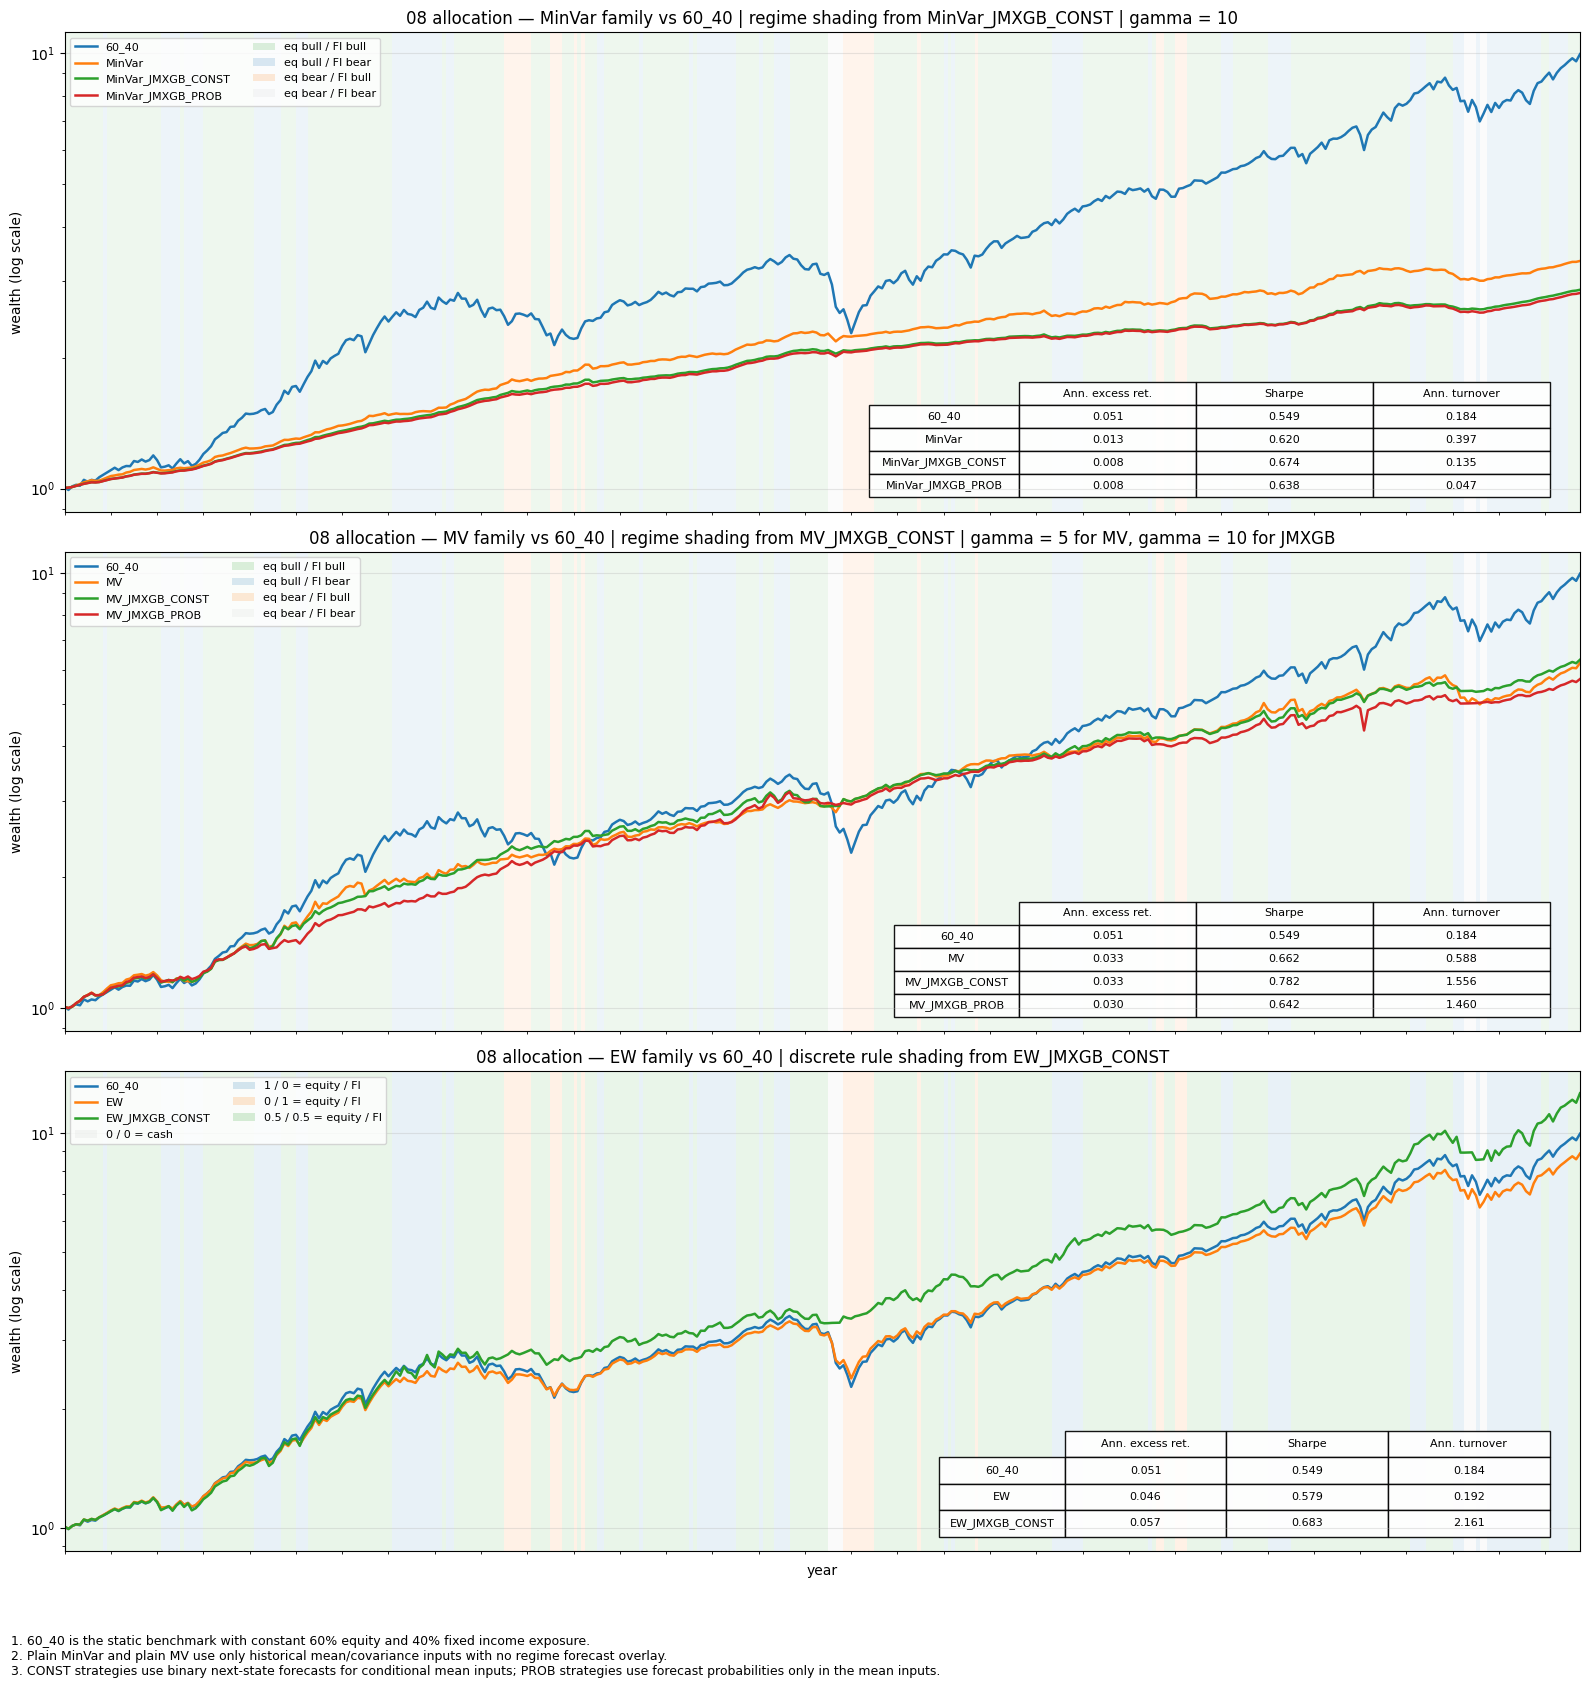

In [96]:
weights_lookup = {
    s: allocation_weights_long.loc[allocation_weights_long["strategy"] == s].sort_values("date").reset_index(drop=True)
    for s in allocation_weights_long["strategy"].unique()
}

def contiguous_spans(mask_series: pd.Series):
    mask_series = mask_series.fillna(False).astype(bool)
    spans = []
    start = None
    prev_date = None
    for dt, val in zip(mask_series.index, mask_series.values):
        if val and start is None:
            start = dt
        if (not val) and start is not None:
            spans.append((start, prev_date))
            start = None
        prev_date = dt
    if start is not None:
        spans.append((start, prev_date))
    return spans

def add_rule_shading(ax, rule_df: pd.DataFrame):
    shade_specs = [
        ("cash", (rule_df["target_w_equity"] == 0.0) & (rule_df["target_w_bond"] == 0.0), "lightgray", "0 / 0 = cash"),
        ("equity_only", (rule_df["target_w_equity"] == 1.0) & (rule_df["target_w_bond"] == 0.0), "tab:blue", "1 / 0 = equity / FI"),
        ("bond_only", (rule_df["target_w_equity"] == 0.0) & (rule_df["target_w_bond"] == 1.0), "tab:orange", "0 / 1 = equity / FI"),
        ("balanced", (rule_df["target_w_equity"] == 0.5) & (rule_df["target_w_bond"] == 0.5), "tab:green", "0.5 / 0.5 = equity / FI"),
    ]
    legend_handles = []
    for _, mask, color, label in shade_specs:
        spans = contiguous_spans(pd.Series(mask.values, index=rule_df["date"]))
        for start, end in spans:
            ax.axvspan(start, end + pd.offsets.MonthEnd(1), color=color, alpha=0.10, lw=0, zorder=0)
        legend_handles.append(Patch(facecolor=color, edgecolor="none", alpha=0.18, label=label))
    return legend_handles

def add_regime_pair_shading(ax, rule_df: pd.DataFrame):
    shade_specs = [
        ("bb", (rule_df["eq_pred_bull_binary"] == 1) & (rule_df["bond_pred_bull_binary"] == 1), "tab:green", "eq bull / FI bull"),
        ("bn", (rule_df["eq_pred_bull_binary"] == 1) & (rule_df["bond_pred_bull_binary"] == 0), "tab:blue", "eq bull / FI bear"),
        ("nb", (rule_df["eq_pred_bull_binary"] == 0) & (rule_df["bond_pred_bull_binary"] == 1), "tab:orange", "eq bear / FI bull"),
        ("nn", (rule_df["eq_pred_bull_binary"] == 0) & (rule_df["bond_pred_bull_binary"] == 0), "lightgray", "eq bear / FI bear"),
    ]
    legend_handles = []
    for _, mask, color, label in shade_specs:
        spans = contiguous_spans(pd.Series(mask.values, index=rule_df["date"]))
        for start, end in spans:
            ax.axvspan(start, end + pd.offsets.MonthEnd(1), color=color, alpha=0.08, lw=0, zorder=0)
        legend_handles.append(Patch(facecolor=color, edgecolor="none", alpha=0.16, label=label))
    return legend_handles

def add_stats_table(ax, strategies, summary_df, bbox=(0.63, 0.03, 0.35, 0.24)):
    stats = summary_df.loc[strategies, ["ann_excess_return", "sharpe_ann", "ann_turnover"]].copy()
    stats.columns = ["Ann. excess ret.", "Sharpe", "Ann. turnover"]
    stats = stats.applymap(lambda x: f"{x:.3f}")
    tbl = ax.table(
        cellText=stats.values,
        rowLabels=list(stats.index),
        colLabels=list(stats.columns),
        cellLoc="center",
        rowLoc="center",
        bbox=bbox,
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for _, cell in tbl.get_celld().items():
        cell.set_alpha(0.92)
    return tbl

def add_line_explanations(fig, lines, y=0.015):
    text = "\n".join([f"{i+1}. {line}" for i, line in enumerate(lines)])
    fig.text(0.01, y, text, ha="left", va="bottom", fontsize=9)

fig, axes = plt.subplots(3, 1, figsize=(16, 17), sharex=True)

minvar_strats = ["60_40", "MinVar", "MinVar_JMXGB_CONST", "MinVar_JMXGB_PROB"]
curve_wide[minvar_strats].plot(ax=axes[0], logy=True, lw=1.8)
minvar_rule_df = weights_lookup["MinVar_JMXGB_CONST"][["date", "eq_pred_bull_binary", "bond_pred_bull_binary"]]
minvar_handles = add_regime_pair_shading(axes[0], minvar_rule_df)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles + minvar_handles, labels + [h.get_label() for h in minvar_handles], loc="upper left", ncol=2, fontsize=8)
axes[0].set_title("08 allocation — MinVar family vs 60_40 | regime shading from MinVar_JMXGB_CONST | gamma = 10")
axes[0].set_ylabel("wealth (log scale)")
axes[0].grid(True, alpha=0.3)
apply_year_axis(axes[0])
add_stats_table(axes[0], minvar_strats, summary_lookup)

mv_strats = ["60_40", "MV", "MV_JMXGB_CONST", "MV_JMXGB_PROB"]
curve_wide[mv_strats].plot(ax=axes[1], logy=True, lw=1.8)
mv_rule_df = weights_lookup["MV_JMXGB_CONST"][["date", "eq_pred_bull_binary", "bond_pred_bull_binary"]]
mv_handles = add_regime_pair_shading(axes[1], mv_rule_df)
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles + mv_handles, labels + [h.get_label() for h in mv_handles], loc="upper left", ncol=2, fontsize=8)
axes[1].set_title("08 allocation — MV family vs 60_40 | regime shading from MV_JMXGB_CONST | gamma = 5 for MV, gamma = 10 for JMXGB")
axes[1].set_ylabel("wealth (log scale)")
axes[1].grid(True, alpha=0.3)
apply_year_axis(axes[1])
add_stats_table(axes[1], mv_strats, summary_lookup)

ew_strats = ["60_40", "EW", "EW_JMXGB_CONST"]
curve_wide[ew_strats].plot(ax=axes[2], logy=True, lw=1.8)
ew_rule_df = weights_lookup["EW_JMXGB_CONST"][["date", "target_w_equity", "target_w_bond"]]
ew_handles = add_rule_shading(axes[2], ew_rule_df)
handles, labels = axes[2].get_legend_handles_labels()
axes[2].legend(handles + ew_handles, labels + [h.get_label() for h in ew_handles], loc="upper left", ncol=2, fontsize=8)
axes[2].set_title("08 allocation — EW family vs 60_40 | discrete rule shading from EW_JMXGB_CONST")
axes[2].set_ylabel("wealth (log scale)")
axes[2].set_xlabel("year")
axes[2].grid(True, alpha=0.3)
apply_year_axis(axes[2])
add_stats_table(axes[2], ew_strats, summary_lookup, bbox=(0.66, 0.03, 0.32, 0.22))

add_line_explanations(
    fig,
    [
        "60_40 is the static benchmark with constant 60% equity and 40% fixed income exposure.",
        "Plain MinVar and plain MV use only historical mean/covariance inputs with no regime forecast overlay.",
        "CONST strategies use binary next-state forecasts for conditional mean inputs; PROB strategies use forecast probabilities only in the mean inputs."
    ],
    y=0.01
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


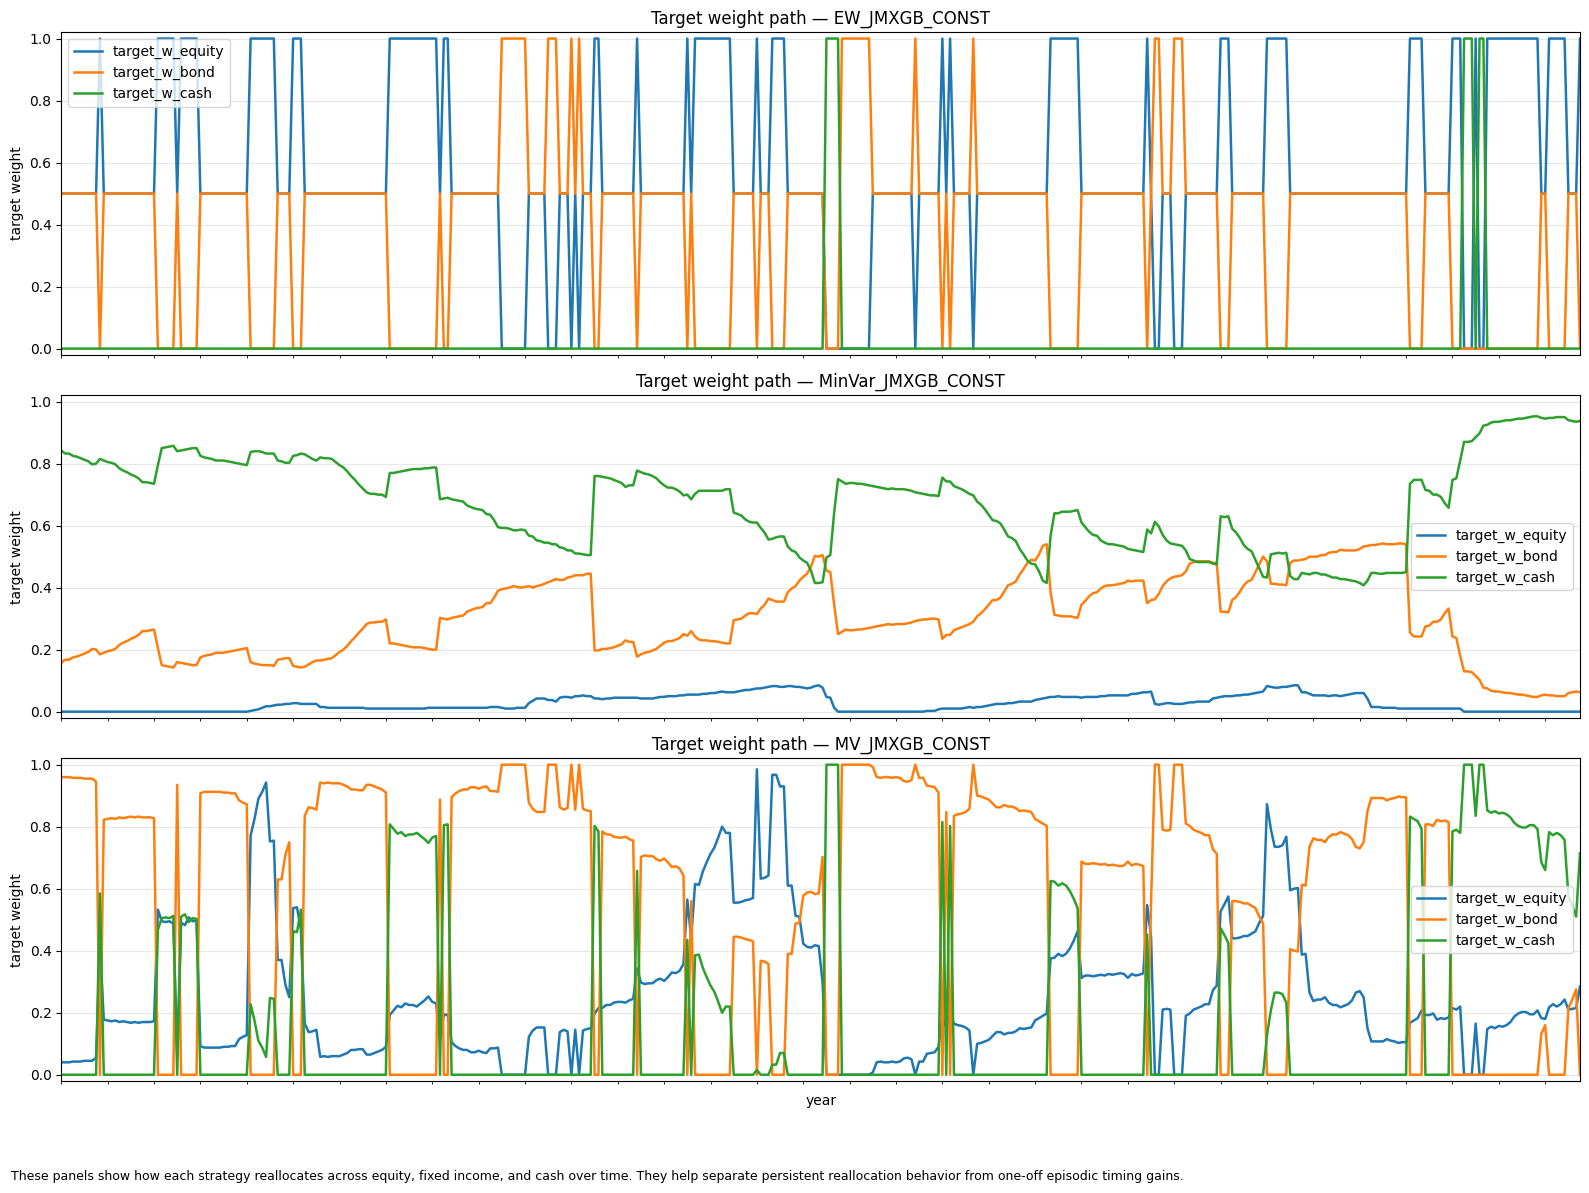

In [97]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, strat in zip(axes, ["EW_JMXGB_CONST", "MinVar_JMXGB_CONST", "MV_JMXGB_CONST"]):
    dfw = weights_lookup[strat].copy()
    dfw = dfw.set_index("date")[["target_w_equity", "target_w_bond", "target_w_cash"]]
    dfw.plot(ax=ax, lw=1.8)
    ax.set_title(f"Target weight path — {strat}")
    ax.set_ylabel("target weight")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(True, alpha=0.3)
    apply_year_axis(ax)

axes[-1].set_xlabel("year")

fig.text(
    0.01, 0.01,
    "These panels show how each strategy reallocates across equity, fixed income, and cash over time. They help separate persistent reallocation behavior from one-off episodic timing gains.",
    ha="left", va="bottom", fontsize=9
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()


In [98]:
print("ALLOCATION_SUMMARY_SORTED_BY_SHARPE")
display_cols = [
    "strategy",
    "ann_excess_return",
    "ann_excess_vol",
    "sharpe_ann",
    "max_drawdown",
    "calmar",
    "ann_turnover",
    "avg_leverage",
    "mean_gamma_risk_used",
]
print(
    allocation_summary
    .sort_values(["group", "sharpe_ann"], ascending=[True, False])[display_cols + ["group"]]
    .to_string(index=False)
)


ALLOCATION_SUMMARY_SORTED_BY_SHARPE
          strategy  ann_excess_return  ann_excess_vol  sharpe_ann  max_drawdown   calmar  ann_turnover  avg_leverage  mean_gamma_risk_used      group
    MV_JMXGB_CONST           0.033272        0.042531    0.782288     -0.079727 0.724438      1.556235      0.822970             10.000000   headline
    EW_JMXGB_CONST           0.057004        0.083508    0.682621     -0.160517 0.499958      2.161210      0.977157                   NaN   headline
MinVar_JMXGB_CONST           0.008242        0.012230    0.673880     -0.033352 0.976383      0.134818      0.324981             10.000000   headline
                MV           0.033093        0.050026    0.661523     -0.142606 0.401117      0.588257      0.944676              5.000000   headline
            MinVar           0.013041        0.021036    0.619945     -0.064073 0.583180      0.396830      0.574867             10.000000   headline
                EW           0.045904        0.079326    0.57867